<a href="https://colab.research.google.com/github/Nick300500/Electricity-Price-Forecast-Battery-Optimization/blob/main/Battery_optimization_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Price Forecasting and Battery Scheduling


# General information

In this script, we tried to analyze, how much profit can accurate electricity price forecasting unlock when operating a residential battery system.

To do so, first we implemented a forecasting model.
Therefore, we set up a dataset with data we thought could be important for the Day-Ahead price.

Then we create a forecasting-model using RandomForest. WIth this model, we forecast a Day-Ahead Price and put it into a given battery optimizer to calculate the profit. As battery, we use the examplary home-storage battery (Sungrow SBR096 with 3 Module and the given data from the datasheet.

Afterwards we also compare the profit of the perfect battery scheduling with the profit we make, using the charging/discharging-behavior from the battery-optimazation, using our forecasted prices and the actual prices of the Day-Ahead.
Finally, we do a sensitivity-analysis to investigate the influence of the price-prediction on our profit.


In our code, we # some displays due to clarity. To visualize them, just remove the #

In [ ]:
#install packages
!pip install pyomo
!pip install highs

ERROR: Could not find a version that satisfies the requirement highs (from versions: none)
ERROR: No matching distribution found for highs


In [ ]:
#import functions
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import os
import pickle
from sklearn.model_selection import (
    train_test_split,  # To split the dataset into training, validation, and test sets
    GridSearchCV,      # For exhaustive hyperparameter tuning using cross-validation
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,  # Measures average magnitude of errors in a set of predictions
    mean_squared_error    # Penalizes larger errors more than MAE by squaring them
)


# Create 'Results' directory if it doesn't exist
if not os.path.exists('Results'):
    os.makedirs('Results')

# Storage optimization function (as provided)

First, we implement the storage optimization function, which was provided to us. This function takes a list of prices and optimizes the charging and discharging behavior of a battery (the characteristics of the battery are the default ones for our example). It gives an output which includes charging, discharging, Energy and profit per timestep (one hour).


In [ ]:
#First of all, here is the optimization function
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu Jun 15 09:10:41 2023

@author: nick

Instructions:
-------------
To run this code, you need to install pyomo for optimization and highs as the solver.
Install with:
    conda install conda-forge::pyomo
    conda install conda-forge::highs

Usage:
------
python opt_func.py

Make sure you have a CSV file with a column 'price' and a datetime or integer index.
"""

import pyomo.environ as pyo
import pandas as pd


def optimize_storage_dispatch(
    price_df,
    storage_params=None,
):
    """
    Optimizes battery storage dispatch to maximize profit given external price time series.

    Returns
    -------
    model : pyomo.ConcreteModel
        Solved Pyomo model.
    """
    # Sensible defaults
    if storage_params is None:
        storage_params = {
            "capacity": 9.6,          #capacity in kWh
            "p_max": 5.76,              #maximum power kW
            "eff_ch": 0.95,           #charging effectivity
            "eff_dis": 0.95,          #discharging effectivity
            "soc_init": 0,            #inital state of charge
        }
    # Ensure price_df is a Series
    if isinstance(price_df, pd.DataFrame):
        price_series = price_df.iloc[:, 0]
    else:
        price_series = price_df

    n_steps = len(price_series)
    model = pyo.ConcreteModel()
    model.T = pyo.RangeSet(0, n_steps - 1)

    # Variables
    model.P_ch = pyo.Var(
        model.T, within=pyo.NonNegativeReals, bounds=(0, storage_params["p_max"])
    )
    model.P_dis = pyo.Var(
        model.T, within=pyo.NonNegativeReals, bounds=(0, storage_params["p_max"])
    )
    model.E = pyo.Var(
        model.T, within=pyo.NonNegativeReals, bounds=(0, storage_params["capacity"])
    )

    # Storage state of charge constraints
    def soc_rule(model, t):
        if t == 0:
            return (
                model.E[t]
                == storage_params["soc_init"]
                + model.P_ch[t] * storage_params["eff_ch"]
                - model.P_dis[t] / storage_params["eff_dis"]
            )
        else:
            return (
                model.E[t]
                == model.E[t - 1]
                + model.P_ch[t] * storage_params["eff_ch"]
                - model.P_dis[t] / storage_params["eff_dis"]
            )

    model.soc = pyo.Constraint(model.T, rule=soc_rule)

    # Objective: maximize profit (revenue from discharge - cost of charge)
    model.obj = pyo.Objective(
        expr=sum(
            price_series.iat[t] * model.P_dis[t] - price_series.iat[t] * model.P_ch[t]
            for t in model.T
        ),
        sense=pyo.maximize,
    )

    # Solve
    solver = pyo.SolverFactory("appsi_highs")
    solver.solve(model)

    return model

def extract_storage_profits(model, price_series, storage_params=None):
    """
    Processes the solved model and outputs a DataFrame with dispatch and profit per time step.
    """
    # Sensible defaults
    if storage_params is None:
        storage_params = {
            "eff_ch": 0.95,
            "eff_dis": 0.95,
        }
    n_steps = len(price_series)
    results_df = pd.DataFrame(
        {
            "P_ch": [pyo.value(model.P_ch[t]) for t in range(n_steps)],
            "P_dis": [pyo.value(model.P_dis[t]) for t in range(n_steps)],
            "E": [pyo.value(model.E[t]) for t in range(n_steps)],
            "price": [price_series.iat[t] for t in range(n_steps)],
        },
        index=price_series.index,
    )
    results_df["profit"] = results_df["price"] * results_df["P_dis"] - results_df["price"] * results_df["P_ch"]

    return results_df

To check, whether it is working correctly, we implement the scenario of perfect prediction, which means the operation of a battery concidering the actual Day-Ahead prices. To check the correct working, we plot also an exemplary timeframe and check, whether the charging happens at local minima and the discharging happens at local maxima.

In [ ]:
#Now we calculate, how much profit in an ideal case
# (forecast price = actual day-ahead price) can be made

if __name__ == "__main__":
    # Example usage
    # Load price data from CSV. The included CSV along this code is just a sample
    # and should be replaced with your actual price data.
    price_csv_path = "price_data.csv"
    price_df = pd.read_csv(price_csv_path, index_col=0)
    # Ensure price column is named 'price'
    if "price" not in price_df.columns:
        raise ValueError("CSV must contain a column named 'price'.")

    # Define storage parameters <- Adjust for your specific project
    storage_params = {
         "capacity": 9.6,             #capacity in kWh
            "p_max": 5.76,            #maximum power kW
            "eff_ch": 0.95,           #charging effectivity
            "eff_dis": 0.95,          #discharging effectivity
            "soc_init": 0,            #inital state of charge
    }

    # Run optimization
    model = optimize_storage_dispatch(price_df["price"], storage_params)

    # Extract profits and dispatch info
    perfect_results_df = extract_storage_profits(model, price_df["price"], storage_params)

    # Print results
    print("Dispatch results (head):")
    print(perfect_results_df.head(104))
    print(f"\nTotal profit: {perfect_results_df['profit'].sum()/1000:.2f}€")

Dispatch results (head):
                         P_ch   P_dis      E  price      profit
Time                                                           
2024-01-01 00:00:00 -0.000000  0.0000  0.000   0.10    0.000000
2024-01-01 01:00:00  0.000000 -0.0000  0.000   0.01   -0.000000
2024-01-01 02:00:00  0.000000 -0.0000  0.000   0.00   -0.000000
2024-01-01 03:00:00  5.760000  5.1984  0.000  -0.01    0.005616
2024-01-01 04:00:00  5.760000  0.0000  5.472  -0.03    0.172800
...                       ...     ...    ...    ...         ...
2024-01-05 03:00:00  5.760000  0.0000  5.472  73.21 -421.689600
2024-01-05 04:00:00  4.345263  0.0000  9.600  74.05 -321.766737
2024-01-05 05:00:00  0.000000  0.0000  9.600  76.03    0.000000
2024-01-05 06:00:00  0.000000  0.0000  9.600  81.00    0.000000
2024-01-05 07:00:00  0.000000 -0.0000  9.600  87.00   -0.000000

[104 rows x 5 columns]

Total profit: 406.45€


In [ ]:
#We save the dataframe of the maximum possible profil and store it in the
#result folder

output_filename = 'perfect_results_df_2024.csv'
output_path = os.path.join('Results', output_filename)

# Save the DataFrame to a CSV file
perfect_results_df.to_csv(output_path)

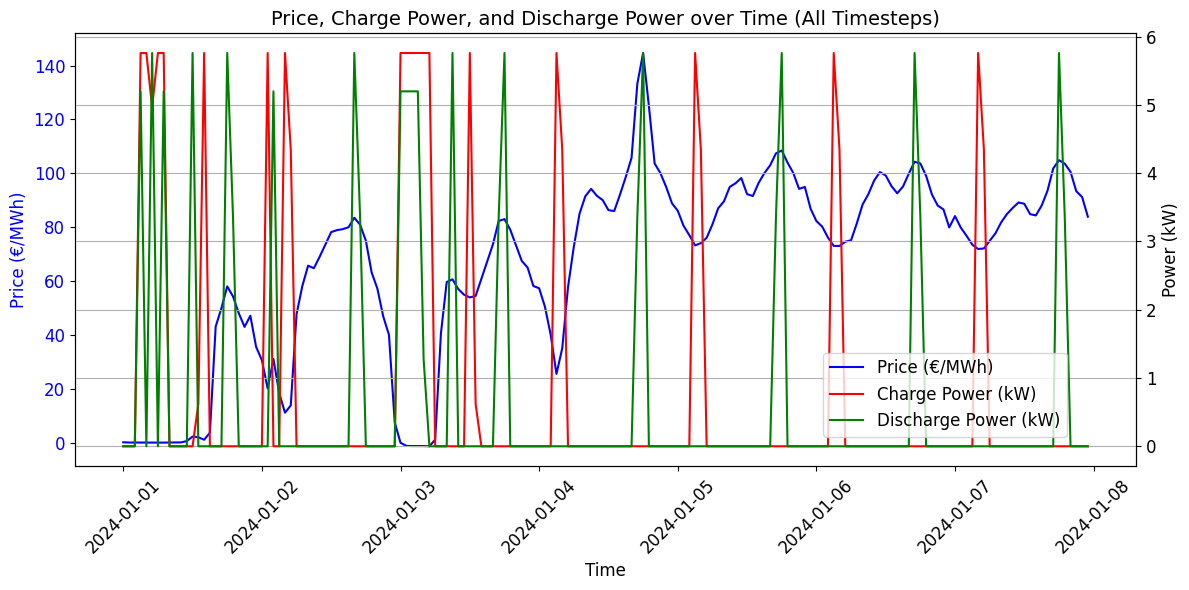

In [ ]:
# Define the path to the results file
results_path = os.path.join('Results', 'perfect_results_df_2024.csv')

# Read the results CSV file into a DataFrame
perfect_results_df = pd.read_csv(results_path, index_col=0)
perfect_results_df.index = pd.to_datetime(perfect_results_df.index)
#Create a subset for better readability of the plot
result_subset_df = perfect_results_df.head(168)

fig, ax1 = plt.subplots(figsize=(12, 6))

 # Plot price on the first y-axis
ax1.plot(result_subset_df.index, result_subset_df['price'], color='blue', label='Price (€/MWh)')
ax1.set_xlabel('Time',fontsize=12)
ax1.set_ylabel('Price (€/MWh)', color='blue',fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)


# Format x-axis as days
ax1.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)



# Create a second y-axis for power
ax2 = ax1.twinx()
ax2.plot(result_subset_df.index, result_subset_df['P_ch'], color='red', label='Charge Power (kW)')
ax2.plot(result_subset_df.index, result_subset_df['P_dis'], color='green', label='Discharge Power (kW)')
ax2.set_ylabel('Power (kW)', color='black',fontsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='x', labelsize=12)

ax2.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Add title and legend
plt.title('Price, Charge Power, and Discharge Power over Time (All Timesteps)',fontsize=14)
fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.25), fontsize=12)

#Show the plot
plt.tight_layout()
plt.grid(True)
plt.show()

Aa we can see, the optimizer tells our battery to charge at local price-minimas and to discharge at local price-maximas. This verifies that the function works as it should.

# Preparing data for the forecast

To build a Day-Ahead forecasting model, we need DataFrames to train and test our model on. Therefore, we prepare data which we think could effect the Day-Ahead price and should be therefore given to our model. To combine all data into one DataFrame, different index-changes and adaptions have to be made. Also some time data gets quantified (like e.g. weekday, daytime or month), to also include a time-dependancy in the data.

In [ ]:
#Load all data from the csv-Files from the sample_data-Folder

price_2024_df = pd.read_csv('price_data.csv')


# Load price_2023_df, skipping the first row
price_2023_df = pd.read_csv('price_data_2023 and others non forecasted.csv', skiprows=[1]) # Skip the first row (index 0 after header)
price_2023_df = price_2023_df.drop(columns=['Date (GMT+1)'])
price_2023_df = price_2023_df.drop(columns=['Hydro pumped storage consumption',
                                            'Cross border electricity trading',
                                            'Nuclear',
                                            'Non-Renewable',
                                            'Renewable',
                                            #'CO2 Emission Allowances, Auction DE',
                                            #'CO2 Emission Allowances, Auction EU'
                                            ])
price_2023_df = price_2023_df.rename(columns={'Day Ahead Auction (DE-LU)': 'price'})

#Load prices from 2025 (until end of June)
price_CO2_df_2025 = pd.read_csv('price_CO2_2025.csv', delimiter=',', skiprows=[1])
price_CO2_df_2025 = price_CO2_df_2025.drop(columns=['Datum (MEZ)'])
price_CO2_df_2025 = price_CO2_df_2025.rename(columns={'Day Ahead Auktion (DE-LU)': 'price',
                                                      'CO2 Emissionszertifikate, Auktion DE':
                                                      'CO2 Emission Allowances, Auction DE',
                                                      'CO2 Emissionszertifikate, Auktion EU':
                                                      'CO2 Emission Allowances, Auction EU'})



#To make the .csv-Files readable, we separate them at the ;
gen_df_2024 = pd.read_csv('gen_2024.csv', delimiter=',')


load_df_2024 = pd.read_csv('load_2024.csv', delimiter=';')


gen_df_2023 = pd.read_csv('gen_2023.csv', delimiter=',')


load_df_2023 = pd.read_csv('load_2023.csv', delimiter=';')

CO2_auction_df = pd.read_csv('CO2_2024.csv', delimiter=',', skiprows=[1])

gen_df_2025 = pd.read_csv('gen_2025.csv', delimiter=',')

load_df_2025 = pd.read_csv('load_2025.csv', delimiter=';')

gas_price_2023 = pd.read_csv('gas_price_2023.csv')

gas_price_2024 = pd.read_csv('gas_price_2024.csv')

gas_price_2025 = pd.read_csv('gas_price_2025.csv')

coal_23_24 = pd.read_csv('coal_23_24.csv', delimiter=';')

coal_25 = pd.read_csv('coal_25.csv', delimiter=';')

# Select rows until the 30th of June
price_CO2_df_2025 = price_CO2_df_2025.iloc[0:4343]
#display(price_CO2_df_2025)
#display(gen_df_2025)
#display(load_df_2025)

In [ ]:
# remove first index of gas_price

gas_price_2023 = gas_price_2023.drop(gas_price_2023.index[0])
gas_price_2024 = gas_price_2024.drop(gas_price_2024.index[0])
gas_price_2025 = gas_price_2025.drop(gas_price_2025.index[0])

# change gas price to 24 h steps. Takeing each gas price and write it 24 times

g_price_23 = []
for x in gas_price_2023['Gas (NCG, THE)']:
  for y in range(0,24):
    g_price_23.append(x)

gas_price_2023_df = pd.DataFrame(g_price_23)
gas_price_2023_df = gas_price_2023_df.rename(columns={0: 'gas_price'})

g_price_24 = []
for x in gas_price_2024['Gas (NCG, THE)']:
  for y in range(0,24):
    g_price_24.append(x)

gas_price_2024_df = pd.DataFrame(g_price_24)
gas_price_2024_df = gas_price_2024_df.rename(columns={0: 'gas_price'})


g_price_25 = []
for x in gas_price_2025['Gas (NCG, THE)']:
  for y in range(0,24):
    g_price_25.append(x)

gas_price_2025_df = pd.DataFrame(g_price_25)
gas_price_2025_df = gas_price_2025_df.rename(columns={0: 'gas_price'})


# combine gas_price 23 and 24

gas_price_df_23_24 = pd.concat([gas_price_2023_df, gas_price_2024_df], ignore_index=True)

#display(gas_price_df_23_24)

In [ ]:
# calculate average of every two prices in coal_23_24

coal_23_24['2_step'] = coal_23_24.index // 2

# Clean the 'price' column: replace comma with dot and convert to numeric
coal_23_24['price'] = coal_23_24['price'].astype(str).str.replace(',', '.', regex=False)
coal_23_24['price'] = pd.to_numeric(coal_23_24['price'], errors='coerce')


coal_23_24_avg = coal_23_24.groupby('2_step')['price'].mean().reset_index(drop=True)

# Create a list to store the hourly coal prices
hourly_coal_prices = []

# Iterate through each row of the coal_23_24_avg DataFrame
for index, monthly_avg in coal_23_24_avg.items():
    # Determine the month and year based on the index
    month = (index % 12) + 1
    year = 2023 + (index // 12)

    # Calculate the number of days in the current month
    num_days = pd.Period(f'{year}-{month}').days_in_month

    # Calculate the number of hours in the current month
    num_hours = num_days * 24

    # Append the monthly average price repeated for each hour of the month
    hourly_coal_prices.extend([monthly_avg] * num_hours)

# Create a new DataFrame with the hourly coal prices
hourly_coal_price_24_df = pd.DataFrame({'hourly_coal_price': hourly_coal_prices})


# calculate average of every two prices in coal_25

coal_25['2_step'] = coal_25.index // 2

# Clean the 'price' column: replace comma with dot and convert to numeric
coal_25['price'] = coal_25['price'].astype(str).str.replace(',', '.', regex=False)
coal_25['price'] = pd.to_numeric(coal_25['price'], errors='coerce')


coal_25_avg = coal_25.groupby('2_step')['price'].mean().reset_index(drop=True)

# Create a list to store the hourly coal prices
hourly_coal_prices = []

# Iterate through each row of the coal_25_avg DataFrame
for index, monthly_avg in coal_25_avg.items():
    # Determine the month and year based on the index
    month = (index % 12) + 1
    year = 2023 + (index // 12)

    # Calculate the number of days in the current month
    num_days = pd.Period(f'{year}-{month}').days_in_month

    # Calculate the number of hours in the current month
    num_hours = num_days * 24

    # Append the monthly average price repeated for each hour of the month
    hourly_coal_prices.extend([monthly_avg] * num_hours)

# Create a new DataFrame with the hourly coal prices
hourly_coal_price_25_df = pd.DataFrame({'hourly_coal_price': hourly_coal_prices})

# Display the first and last 10 rows of the new DataFrame
#display(hourly_coal_price_25_df.head(10))
#display(hourly_coal_price_25_df.tail(10))

# Display the first and last 10 rows of the new DataFrame
#display(hourly_coal_price_24_df.head(10))
#display(hourly_coal_price_24_df.tail(10))


We merge all data (of 2023 and 2024) into one DataFrame with which we want to test, train and validate our model. We also create a new DataFrame with the same data for the first half of 2025. With this dataframe, we want to analyse, how good our forecast is working.

In [ ]:
#Create a new DataFrame including potentially relevant data for the forecast
#Create a new testrun DataFrame for the final comparison between forecast and
#actual prices

#Add CO2 auctions for 2024 to price dataframes
price_2024_df['CO2 Emission Allowances, Auction DE'] = CO2_auction_df['CO2 Emission Allowances, Auction DE']
price_2024_df['CO2 Emission Allowances, Auction EU'] = CO2_auction_df['CO2 Emission Allowances, Auction EU']


#Adding the 2023 prices to the df
forecasting_data = pd.concat([price_2023_df, price_2024_df], ignore_index=True)
#If forecasting_data includes 'Date (GMT+1)' or 'Time': Drop
if 'Date (GMT+1)' in forecasting_data.columns:
  forecasting_data = forecasting_data.drop(columns = ['Date (GMT+1)'])
if 'Time' in forecasting_data.columns:
  forecasting_data = forecasting_data.drop(columns = ['Time'])


#Creating a testrun DataFrame
testrun_df = price_CO2_df_2025

#Add gen and load of 2023 and 2024 to one data frame
gen_df = pd.concat([gen_df_2023, gen_df_2024], ignore_index=True)
gen_df = gen_df.drop(columns = ['Datum bis'])

gen_df_2025_test = gen_df_2025.drop(columns = ['Datum bis'])

load_df = pd.concat([load_df_2023, load_df_2024], ignore_index=True)
load_df = load_df.drop(columns = ['Datum bis'])

load_df_2025_test = load_df_2025.drop(columns = ['Datum bis'])



# Add all relevant parameters to the training data
forecasting_data['time'] = gen_df['Datum von']
forecasting_data['net_load [MWh]'] = load_df['Netzlast [MWh] Berechnete Auflösungen']
forecasting_data['res_load [MWh]'] = load_df['Residuallast [MWh] Berechnete Auflösungen']
forecasting_data['total_gen [MWh]'] = gen_df['Gesamt [MWh] Berechnete Auflösungen']
forecasting_data['solar_gen [MWh]'] = gen_df['Photovoltaik [MWh] Berechnete Auflösungen']
forecasting_data['wind_gen_off [MWh]'] = gen_df['Wind Offshore [MWh] Berechnete Auflösungen']
forecasting_data['wind_gen_on [MWh]'] = gen_df['Wind Onshore [MWh] Berechnete Auflösungen']
forecasting_data['other_gen [MWh]'] = gen_df['Sonstige [MWh] Originalauflösungen']
forecasting_data['gas_price [EUR/MWh]'] = gas_price_df_23_24['gas_price']
forecasting_data['coal_price [EUR/t]'] = hourly_coal_price_24_df['hourly_coal_price']


# Add all relevant parameters to the testrun data (2025)
testrun_df['time'] = gen_df_2025_test['Datum von']
testrun_df['net_load [MWh]'] = load_df_2025_test['Netzlast [MWh] Berechnete Auflösungen']
testrun_df['res_load [MWh]'] = load_df_2025_test['Residuallast [MWh] Berechnete Auflösungen']
testrun_df['total_gen [MWh]'] = gen_df_2025_test['Gesamt [MWh] Berechnete Auflösungen']
testrun_df['solar_gen [MWh]'] = gen_df_2025_test['Photovoltaik [MWh] Berechnete Auflösungen']
testrun_df['wind_gen_off [MWh]'] = gen_df_2025_test['Wind Offshore [MWh] Berechnete Auflösungen']
testrun_df['wind_gen_on [MWh]'] = gen_df_2025_test['Wind Onshore [MWh] Berechnete Auflösungen']
testrun_df['other_gen [MWh]'] = gen_df_2025_test['Sonstige [MWh] Originalauflösungen']
testrun_df['gas_price [EUR/MWh]'] = gas_price_2025_df['gas_price']
testrun_df['coal_price [EUR/t]'] = hourly_coal_price_25_df['hourly_coal_price']


# Convert all relevant colums to the numeric system (to be able to sum them up)
cols_to_convert = ['net_load [MWh]', 'res_load [MWh]', 'total_gen [MWh]',
                   'solar_gen [MWh]', 'wind_gen_off [MWh]', 'wind_gen_on [MWh]',
                   'other_gen [MWh]']

for col in cols_to_convert:
    forecasting_data[col] = forecasting_data[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    testrun_df[col] = testrun_df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)

forecasting_data[cols_to_convert] = forecasting_data[cols_to_convert].apply(pd.to_numeric, errors='coerce')
testrun_df[cols_to_convert] = testrun_df[cols_to_convert].apply(pd.to_numeric, errors='coerce')


# Calculate the difference after converting the columns
forecasting_data['diff_load_gen [MWh]'] = forecasting_data['total_gen [MWh]'] - forecasting_data['net_load [MWh]']
testrun_df['diff_load_gen [MWh]'] = testrun_df['total_gen [MWh]'] - testrun_df['net_load [MWh]']


#Add historical day-ahead prices to the dataset
#ATTENTION! UNtil first repetition occurs, no value given
forecasting_data['DA_price_1_day_before'] = forecasting_data['price'].shift(24)
forecasting_data['DA_price_2_days_before'] = forecasting_data['price'].shift(48)
forecasting_data['DA_price_1_week_before'] = forecasting_data['price'].shift(168)

testrun_df['DA_price_1_day_before'] = testrun_df['price'].shift(24)
testrun_df['DA_price_2_days_before'] = testrun_df['price'].shift(48)
testrun_df['DA_price_1_week_before'] = testrun_df['price'].shift(168)

#Add weekday and month to the data
start_date = '2023-01-01'
hours = 17544 # 2 years
hours_2025 = 4343
date_range = pd.date_range(start=start_date, periods=hours, freq='h')
data_range_2025 = pd.date_range(start=start_date, periods=hours_2025, freq='h')
date_data = pd.DataFrame(index=date_range)
date_data_2025 = pd.DataFrame(index=data_range_2025)

# Extract the day of the week and assign it to the 'weekday' column
# Monday=0, Sunday=6
forecasting_data['weekday'] = date_data.index.dayofweek
forecasting_data['month'] = date_data.index.month

#Add hour to each DataFrame
time_2023_2024 = []
for hour in forecasting_data['time']:
  time_2023_2024.append(hour[-5:-3])
forecasting_data['hour'] = time_2023_2024

time_2025 = []
for hour in testrun_df['time']:
  time_2025.append(hour[-5:-3])
testrun_df['hour'] = time_2025

#convert hour column into float
forecasting_data['hour'] = forecasting_data['hour'].astype(float)
testrun_df['hour'] = testrun_df['hour'].astype(float)

testrun_df['weekday'] = date_data_2025.index.dayofweek
testrun_df['month'] = date_data_2025.index.month

#Safe forecasting and testrun to .csv and store in sample_data folder
forecasting_data.to_csv('forecasting_data.csv')
testrun_df.to_csv('testrun_df.csv')


#display forecasting_data (examplary part of it)
#display(forecasting_data)
#display(testrun_df)
#forecasting_data.head(25)

# Implement the random forest model

Now, we are going to implement our random forest model. As our test-data, we use all data from 2023 and 2024. We let our test run for the data of the first half of 2025. We create our forecast-model using the training-data and the randomforest regressor.

First, we split our forecasting_data into train and validation. We use the validation-data to tune our hyperparameteres and the train-data to train the RandomForest. To test, we then use later the data for 2025.

In [ ]:
# ===========================================
# Random forest model
# ===========================================


# Revoing "-", because it can't be converted from str to float
forecasting_data_new = forecasting_data.replace('-', np.nan)


# Converting all strings in float
forecasting_data_nt = forecasting_data_new.drop(columns=['time'])
forecasting_data_float = forecasting_data_nt.astype(float)


# Using sklearn shuffle split
features = forecasting_data_float.drop('price', axis=1)
target = forecasting_data_float['price']


# Perform a train-validation split
random_state = 42  # For reproducibility
perform_shuffle = False  # Don´t shuffle do to data-leakage

# split our data into train and validation
X_train, X_val, y_train, y_val = train_test_split(features, target,
                                                  test_size=0.1, random_state=random_state,
                                                  shuffle=perform_shuffle)


# Print shapes to verify splits
print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}")

Train set: (15789, 18), Validation set: (1755, 18)


In [ ]:
# Step 1: Instantiate your RandomForestRegressor here
rf_model = RandomForestRegressor(n_estimators=180, max_depth=10,
                                 random_state= random_state)

# Step 2: Fit the model to the training data
rf_model.fit(features, target)

# Step 3: Predict on the training_set and validation set
y_pred_train_rf = rf_model.predict(X_train)
y_pred_val_rf = rf_model.predict(X_val)

# Step 4: Evaluate MAE and RMSE for training and validation
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))

mae_val_rf = mean_absolute_error(y_val, y_pred_val_rf)
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_pred_val_rf))

# Step 5: Print your results
print('Training MAE:', mae_train_rf)
print('Validation MAE:', mae_val_rf)
print('Training RMSE:', rmse_train_rf)
print('Validation RMSE:', rmse_val_rf)


# Step 6: Save the model to a file using pickle
os.makedirs('outputs', exist_ok=True) # Create the 'outputs' folder if it doesn't exist
with open('outputs/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)



Training MAE: 7.307906035687609
Validation MAE: 7.650966324027079
Training RMSE: 10.07002542259087
Validation RMSE: 10.995903405089788


In [ ]:
# Hyperparameter Tuning
esti = range(100,201,10)
depth = range(5,11,1)
# Grid Search over number of trees and max depth
param_grid = {
    'n_estimators': list(esti),     # Number of trees in the forest
    'max_depth': list(depth)    # Maximum depth of each tree
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error'  # Use negative MAE for minimization
)

grid_rf.fit(X_train, y_train)

print('Best RF Params:', grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
y_pred_val_best = best_rf.predict(X_val)
print('Tuned RF MAE:', mean_absolute_error(y_val, y_pred_val_best))

KeyboardInterrupt: 

To increase the quality of our prediction, we tune the hyperparameters (number of estimators and depth of each tree). The result of the tuning is:

n_estimators: 180
max_depth: 10


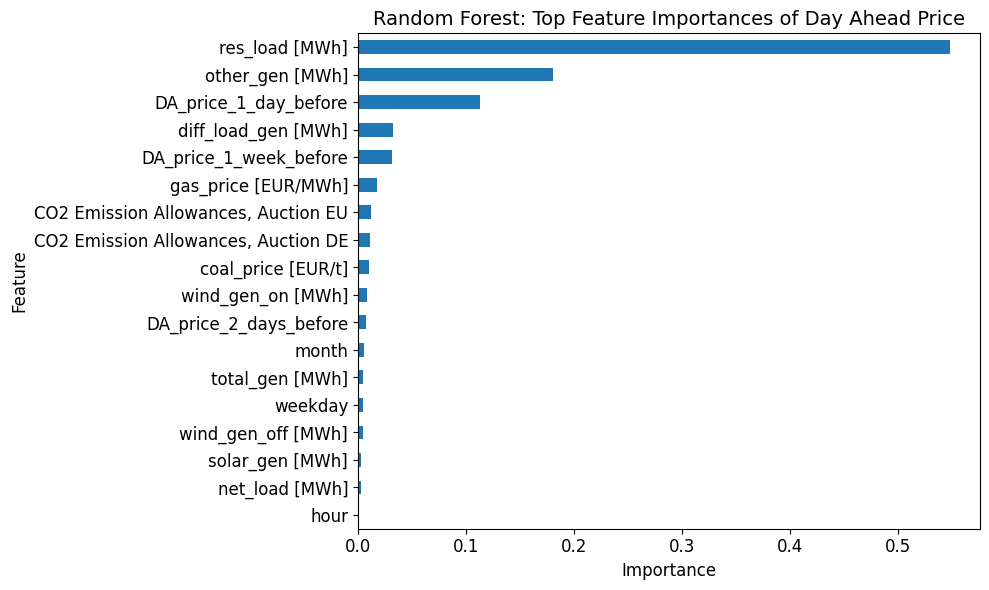

In [ ]:
# Plotting importance of different features

#Load RandomForest model
with open('outputs/rf_model.pkl', 'rb') as f:
    loaded_rf = pickle.load(f)
# Ensure you have the feature names
feature_names_pos = X_train.columns

# --- Random Forest Feature Importance ---
rf_importances_pos = pd.Series(loaded_rf.feature_importances_,
                               index=feature_names_pos).sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Random Forest
rf_importances_pos.plot(kind='barh', ax=ax)
ax.set_title("Random Forest: Top Feature Importances of Day Ahead Price", fontsize=14)
ax.set_xlabel("Importance", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Now we also want to plot the forecasted against the predicted Day-Ahead price to become a feeling on how close these values are to each other.

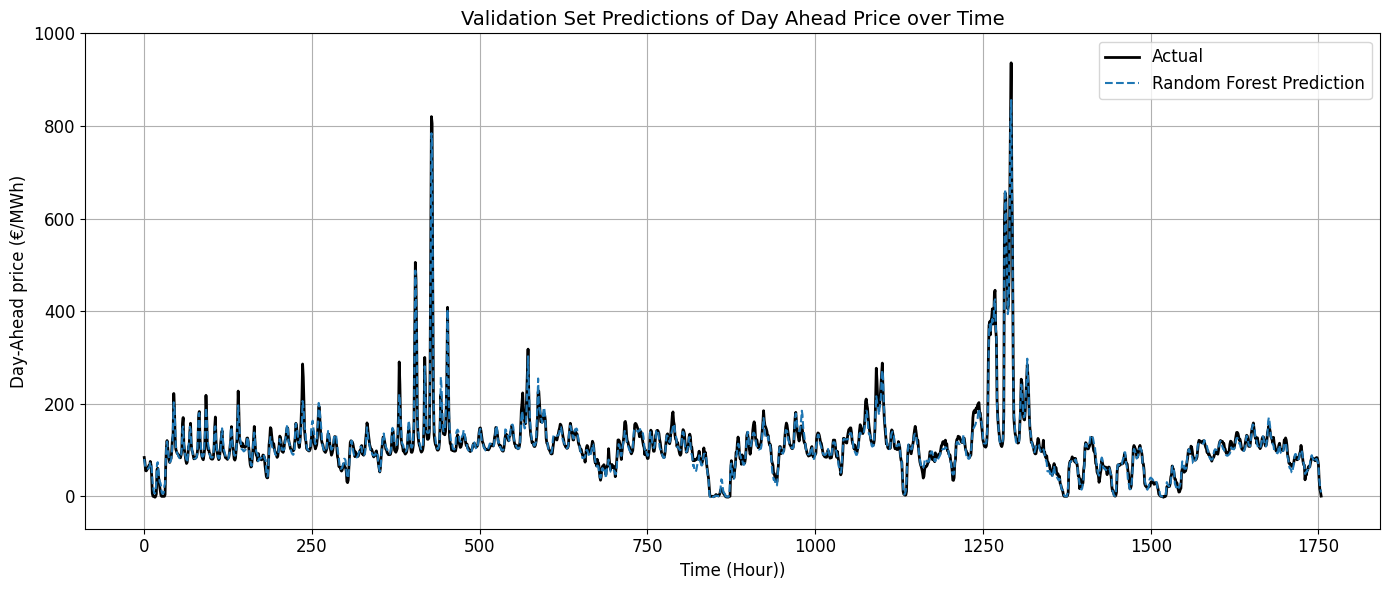

In [ ]:
# ============================================
# Time Series Comparison: Predicted vs. Actual
# ============================================


# Create an index for plotting (assumes original ordering is preserved)
time_index_pos = range(len(y_val))

plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(time_index_pos, y_val, label='Actual', color='black', linewidth=2)

# Plot Random Forest predictions
plt.plot(time_index_pos, y_pred_val_rf, label='Random Forest Prediction', linestyle='--')

plt.xlabel("Time (Hour))", fontsize=12)
plt.ylabel("Day-Ahead price (€/MWh)", fontsize=12)
plt.title("Validation Set Predictions of Day Ahead Price over Time", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.ylim(-70, 1000)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

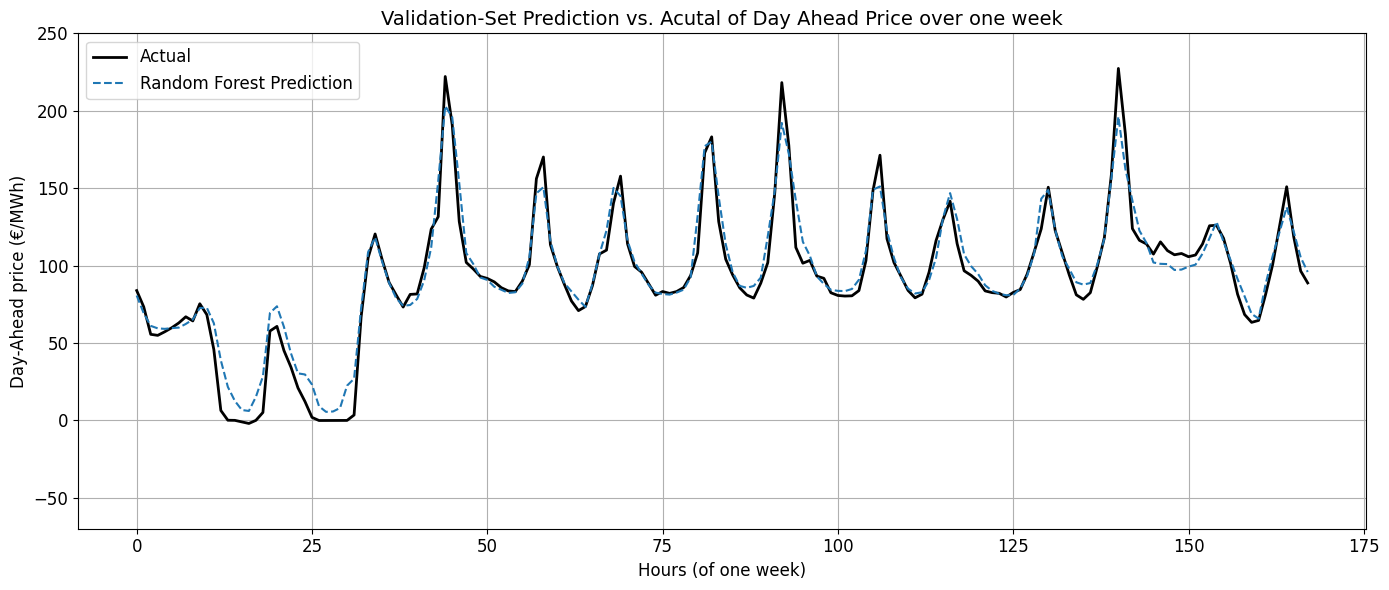

In [ ]:
# Plotting the first 168 time steps of the test set predictions vs actual
plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(time_index_pos[:168], y_val[:168], label='Actual', color='black', linewidth=2)

# Plot Random Forest predictions
plt.plot(time_index_pos[:168], y_pred_val_rf[:168], label='Random Forest Prediction', linestyle='--')

plt.xlabel("Hours (of one week)", fontsize=12)
plt.ylabel("Day-Ahead price (€/MWh)", fontsize=12)
plt.title("Validation-Set Prediction vs. Acutal of Day Ahead Price over one week", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.ylim(-70, 250)  # Keep the same y-axis limits for consistency
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

# Forecasting 2025

Now we want to analyze, how well our forecasting model works and how much profit we could have generated in the first half of 2025. Therefore we first calculate, how much profit our optimizer generates if our forecast would work perfectly. Therefore, we use the actual day-ahead prices of 2025 and feed those prices into our optimazor. The result is the maximum profit, we could have generated with the battery, defined in the optimizor.

In [ ]:
#Now we calculate, how much profit in an ideal case can be made in 2025
# (forecast price = actual day-ahead price) can be made

if __name__ == "__main__":
    # Example usage
    # Load price data from CSV. The included CSV along this code is just a sample
    # and should be replaced with your actual price data.
    price_csv_path = "testrun_df.csv"
    price_df = pd.read_csv(price_csv_path, index_col=4)
    # Ensure price column is named 'price'
    if "price" not in price_df.columns:
        raise ValueError("CSV must contain a column named 'price'.")

    # Define storage parameters <- Adjust for your specific project
    storage_params = {
        "capacity": 9.6,             #capacity in kWh
            "p_max": 5.76,            #maximum power kW
            "eff_ch": 0.95,           #charging effectivity
            "eff_dis": 0.95,          #discharging effectivity
            "soc_init": 0,            #inital state of charge
    }

    # Run optimization
    model = optimize_storage_dispatch(price_df["price"], storage_params)

    # Extract profits and dispatch info
    perfect_results_df_2025 = extract_storage_profits(model, price_df["price"], storage_params)

    #Calculate avergae price for 2025
    average_price_2025 = price_df['price'].mean()
    # Print results
    print("Dispatch results (head):")
    print(perfect_results_df_2025.head(104))
    theoretical_total_profit = perfect_results_df_2025['profit'].sum()/1000
    print(f"\nTheoretical profit: {theoretical_total_profit:.2f} €")
    print(f"\nAverage price 2025: {average_price_2025:.2f} €/MWh")

Dispatch results (head):
                  P_ch   P_dis    E  price    profit
time                                                
01.01.2025 00:00 -0.00  0.0000  0.0   2.16  0.000000
01.01.2025 01:00  0.00 -0.0000  0.0   1.60 -0.000000
01.01.2025 02:00  0.00 -0.0000  0.0   0.00 -0.000000
01.01.2025 03:00  5.76  5.1984  0.0  -0.01  0.005616
01.01.2025 04:00  5.76  5.1984  0.0  -0.01  0.005616
...                ...     ...  ...    ...       ...
05.01.2025 03:00  0.00  0.0000  0.0  93.87  0.000000
05.01.2025 04:00  0.00  0.0000 -0.0  89.38  0.000000
05.01.2025 05:00  0.00  0.0000 -0.0  83.55  0.000000
05.01.2025 06:00  0.00  0.0000 -0.0  83.92  0.000000
05.01.2025 07:00 -0.00  0.0000 -0.0  82.53  0.000000

[104 rows x 5 columns]

Theoretical profit: 247.00 €

Average price 2025: 90.71 €/MWh


In [ ]:
#We save the dataframe of the maximum possible profil and store it in the
#Results folder

output_filename = 'perfect_results_df_2025.csv'
output_path = os.path.join('Results', output_filename)

# Save the DataFrame to a CSV file
perfect_results_df_2025.to_csv(output_path)

Similar as before, we wat to visualize the behavior of the optimizor in relation to the price.

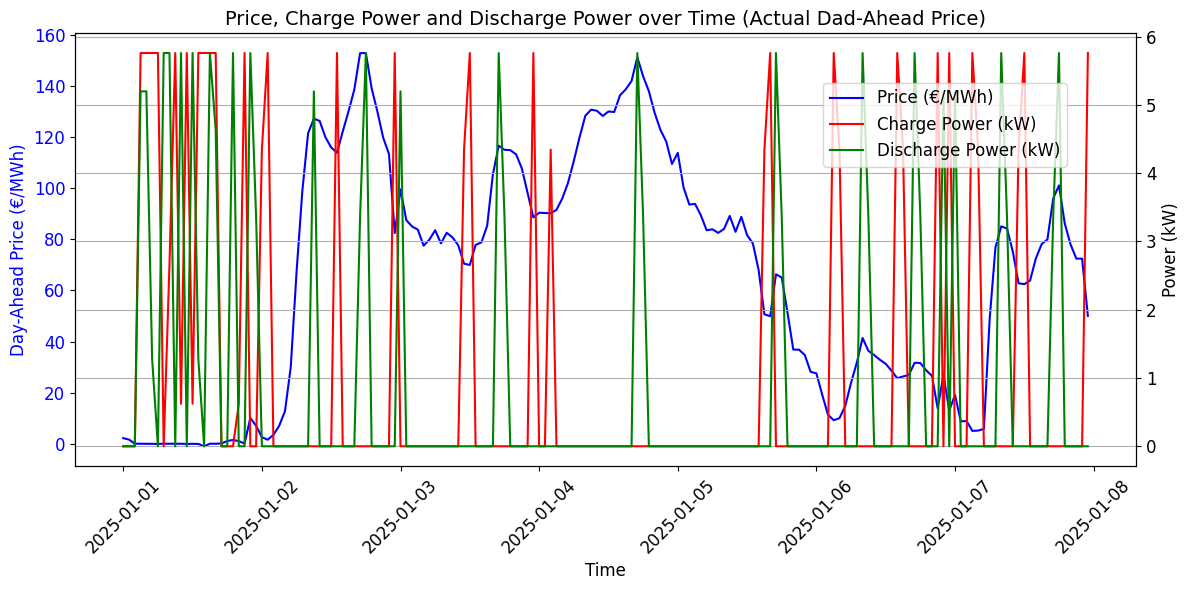

In [ ]:
# Define the path to the results file
results_path = os.path.join('Results', 'perfect_results_df_2025.csv')

# Read the results CSV file into a DataFrame
perfect_results_df_2025 = pd.read_csv(results_path, index_col=0)
# Use the correct format string for conversion
perfect_results_df_2025.index = pd.to_datetime(perfect_results_df_2025.index, format="%d.%m.%Y %H:%M")
#Create a subset for better readability of the plot
result_subset_df_2025 = perfect_results_df_2025.head(168)

fig, ax1 = plt.subplots(figsize=(12, 6))

 # Plot price on the first y-axis
ax1.plot(result_subset_df_2025.index, result_subset_df_2025['price'], color='blue', label='Price (€/MWh)')
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Day-Ahead Price (€/MWh)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)


# Format x-axis as days
ax1.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)



# Create a second y-axis for power
ax2 = ax1.twinx()
ax2.plot(result_subset_df_2025.index, result_subset_df_2025['P_ch'], color='red', label='Charge Power (kW)')
ax2.plot(result_subset_df_2025.index, result_subset_df_2025['P_dis'], color='green', label='Discharge Power (kW)')
ax2.set_ylabel('Power (kW)', color='black', fontsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='x', labelsize=12)


ax2.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Add title and legend
plt.title('Price, Charge Power and Discharge Power over Time (Actual Dad-Ahead Price)', fontsize=14)
fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.7), fontsize=12)

#Show the plot
plt.tight_layout()
plt.grid(True)
plt.show()

Now want wo check, how well our forecast can be used to run the optimizor and to generate profits. Therefore, we first predict the Day-Ahead prices of 2025 using our trained forecast model.
We feed it with the 2025 data (without the given DA-prices) and store the resulting price formation in the Results folder.

In [ ]:
# Select features from testrun_df for forecasting (exclude 'price' and 'time')
# Ensure the columns match the training data (X_train) in name and order

X_forecast = testrun_df[features.columns]

# Use the loaded Random Forest model to make predictions
forecasted_prices = loaded_rf.predict(X_forecast)


# Create a DataFrame for the forecasted prices with the time index from testrun_df
forecasted_prices_df = pd.DataFrame({'forecasted_price': forecasted_prices}, index=testrun_df['time'])


#Save the forecasted_prices as a .csv in the Results folder
forecasted_prices_df.to_csv('Results/forecasted_prices_2025.csv')


# Display the forecasted prices
#print("Forecasted Prices (head):")
#display(forecasted_prices_df.head())

#print("\nForecasted Prices (tail):")
#display(forecasted_prices_df.tail())


In [ ]:
# Calculate the RMSE for our test data
rf_mae = mean_absolute_error(perfect_results_df_2025['price'], forecasted_prices_df['forecasted_price'])
rf_rmse = np.sqrt(mean_squared_error(perfect_results_df_2025['price'], forecasted_prices_df['forecasted_price']))

print(f"Random Forest MAE: {rf_mae:.2f} €/MWh")
print(f"Random Forest RMSE: {rf_rmse:.2f} €/MWh")

Random Forest MAE: 16.43 €/MWh
Random Forest RMSE: 28.32 €/MWh


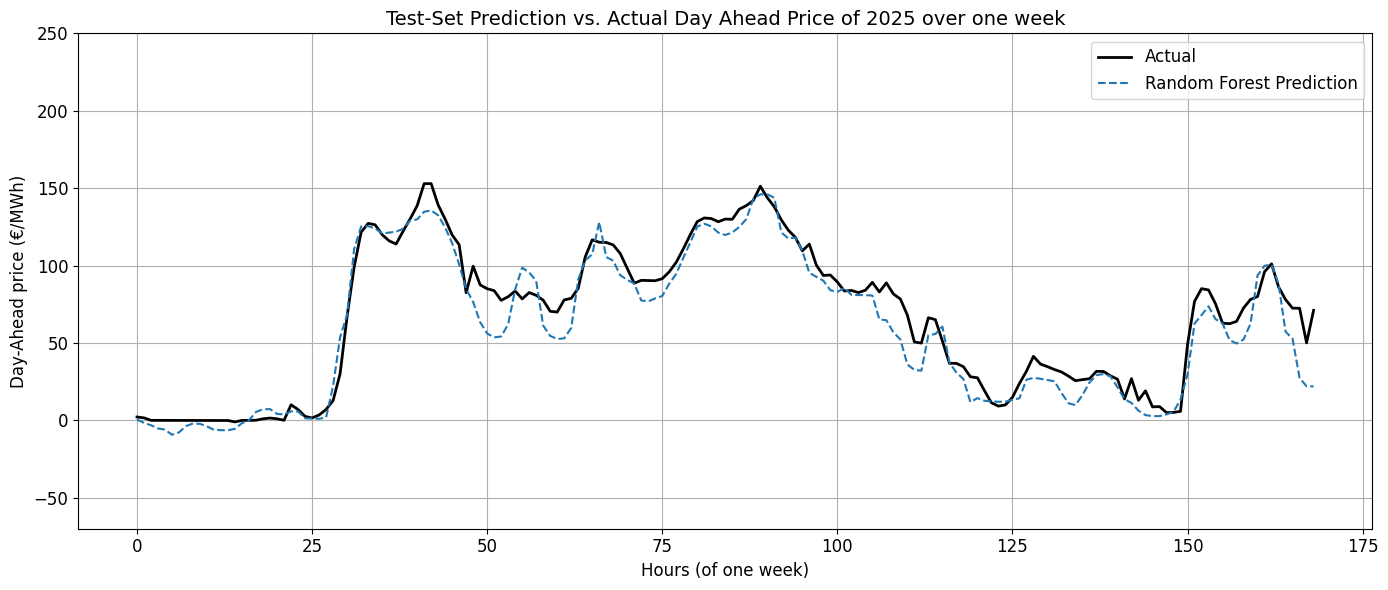

In [ ]:
# Plotting the first 169 time steps of the test set predictions vs actual
plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(testrun_df.index[:169], testrun_df['price'][:169], label='Actual',
         color='black', linewidth=2)

# Plot Random Forest predictions
plt.plot(testrun_df.index[:169], forecasted_prices_df['forecasted_price'][:169],
         label='Random Forest Prediction', linestyle='--')

plt.xlabel("Hours (of one week)", fontsize=12)
plt.ylabel("Day-Ahead price (€/MWh)", fontsize=12)
plt.title("Test-Set Prediction vs. Actual Day Ahead Price of 2025 over one week", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.ylim(-70,250)  # Keep the same y-axis limits for consistency
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

Now we want to calculate, how much profit we can theoredically make, when we use our predicition to optimize our battery, while concidering the predicted Day-Ahead prices are the actual prices (so we assume, the predicted prices of our model are the real ones). We also plot a comparison of the predicted and actual DA-prices. We also plot and save the resulting data in this case.

In [ ]:
#Now we calculate, how much profit we can make, using our predicted prices
# (forecast price = handled as actual day-ahead price) can be made

if __name__ == "__main__":
    # Example usage
    # Load price data from CSV. The included CSV along this code is just a sample
    # and should be replaced with your actual price data.
    price_csv_path = "Results/forecasted_prices_2025.csv"
    price_df = pd.read_csv(price_csv_path, index_col=0)
    # Ensure forecasted price column is named 'price'
    if "forecasted_price" not in price_df.columns:
        raise ValueError("CSV must contain a column named 'forecasted_price'.")

    # Define storage parameters <- Adjust for your specific project
    storage_params = {
        "capacity": 9.6,              #capacity in kWh
            "p_max": 5.76,            #maximum power kW
            "eff_ch": 0.95,           #charging effectivity
            "eff_dis": 0.95,          #discharging effectivity
            "soc_init": 0,            #inital state of charge
    }

    # Run optimization
    model = optimize_storage_dispatch(price_df["forecasted_price"], storage_params)

    # Extract profits and dispatch info
    forecasted_results_df_2025 = extract_storage_profits(model, price_df["forecasted_price"], storage_params)

    #save results as a .csv and store it in the Results folder
    output_filename = 'forecasted_results_df_2025.csv'
    output_path = os.path.join('Results', output_filename)
    forecasted_results_df_2025.to_csv(output_path)


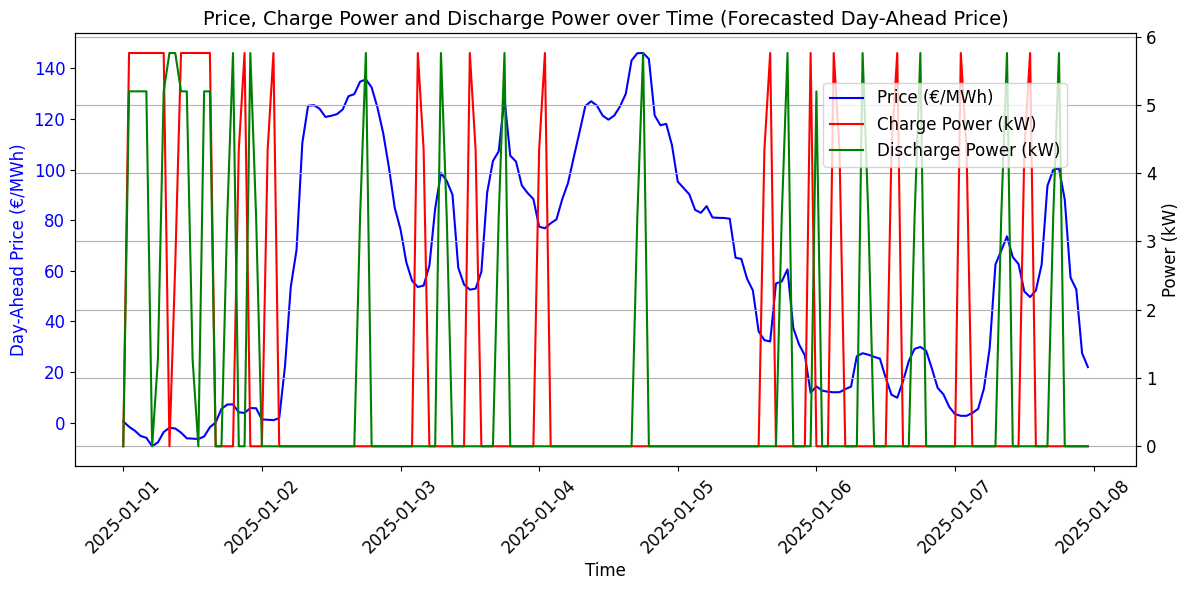

In [ ]:
# Define the path to the results file
results_path = os.path.join('Results', 'forecasted_results_df_2025.csv')

# Read the results CSV file into a DataFrame
forecasted_results_2025 = pd.read_csv(results_path, index_col=0)
# Use the correct format string for conversion
forecasted_results_2025.index = pd.to_datetime(forecasted_results_2025.index,
                                               format="%d.%m.%Y %H:%M")
#Create a subset for better readability of the plot
result_subset_df_2025 = forecasted_results_2025.head(168)

fig, ax1 = plt.subplots(figsize=(12, 6))

 # Plot price on the first y-axis
ax1.plot(result_subset_df_2025.index, result_subset_df_2025['price'], color='blue', label='Price (€/MWh)')
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Day-Ahead Price (€/MWh)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)


# Format x-axis as days
ax1.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)



# Create a second y-axis for power
ax2 = ax1.twinx()
ax2.plot(result_subset_df_2025.index, result_subset_df_2025['P_ch'],
         color='red', label='Charge Power (kW)')
ax2.plot(result_subset_df_2025.index, result_subset_df_2025['P_dis'],
         color='green', label='Discharge Power (kW)')
ax2.set_ylabel('Power (kW)', color='black', fontsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='x', labelsize=12)


ax2.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Add title and legend
plt.title('Price, Charge Power and Discharge Power over Time (Forecasted Day-Ahead Price)', fontsize=14)
fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.7), fontsize=12)

#Show the plot
plt.tight_layout()
plt.grid(True)
plt.show()

Finally, we calculate our "real" profit, which creates itself out of the charge and discharge behavior from our Day-Ahead forecast and the actual Day-Ahead prices. This information helps us calculating the actual difference in profit, related to our forecasting model.

In [ ]:
#Create a new dataframe with P_ch, P_dis and E from forecasted prices
# and price from predicted_results
os.path.join('Results', 'forecasted_results_df_2025.csv')
predicted_results_df_2025 = pd.read_csv('Results/forecasted_results_df_2025.csv', index_col=0)
#First, fixing some index problems

# Create the actual_results_2025 DataFrame by selecting columns from both source dataframes
actual_results_df_2025 = predicted_results_df_2025[['P_ch', 'P_dis', 'E']].copy()

# Set the index of actual_results_df_2025 to match the index of perfect_results_df_2025
# This ensures that the price column is correctly aligned when assigned.
actual_results_df_2025.index = perfect_results_df_2025.index


#Add price to df
actual_results_df_2025['price'] = perfect_results_df_2025['price']

#Calculate profit
actual_results_df_2025['profit'] = (actual_results_df_2025['P_dis']
                                    * actual_results_df_2025['price']
                                    - actual_results_df_2025['P_ch']
                                    * actual_results_df_2025['price'])

#Save the actual results as a .csv files in the Results folder
output_filename = 'actual_results_df_2025.csv'
output_path = os.path.join('Results', output_filename)
actual_results_df_2025.to_csv(output_path)

# Print results
print("Dispatch results (head):")
print(actual_results_df_2025.head(104))
actual_generated_profit = actual_results_df_2025['profit'].sum()/1000
print(f"\nActual profit (forecasted charge/discharge and actual prices): {actual_generated_profit:.2f} €")

Dispatch results (head):
                     P_ch   P_dis    E  price    profit
time                                                   
2025-01-01 00:00:00 -0.00  0.0000  0.0   2.16  0.000000
2025-01-01 01:00:00  5.76  5.1984  0.0   1.60 -0.898560
2025-01-01 02:00:00  5.76  5.1984  0.0   0.00  0.000000
2025-01-01 03:00:00  5.76  5.1984  0.0  -0.01  0.005616
2025-01-01 04:00:00  5.76  5.1984  0.0  -0.01  0.005616
...                   ...     ...  ...    ...       ...
2025-01-05 03:00:00 -0.00  0.0000  0.0  93.87  0.000000
2025-01-05 04:00:00  0.00  0.0000 -0.0  89.38  0.000000
2025-01-05 05:00:00  0.00 -0.0000 -0.0  83.55 -0.000000
2025-01-05 06:00:00  0.00  0.0000 -0.0  83.92  0.000000
2025-01-05 07:00:00  0.00  0.0000 -0.0  82.53  0.000000

[104 rows x 5 columns]

Actual profit (forecasted charge/discharge and actual prices): 233.47 €


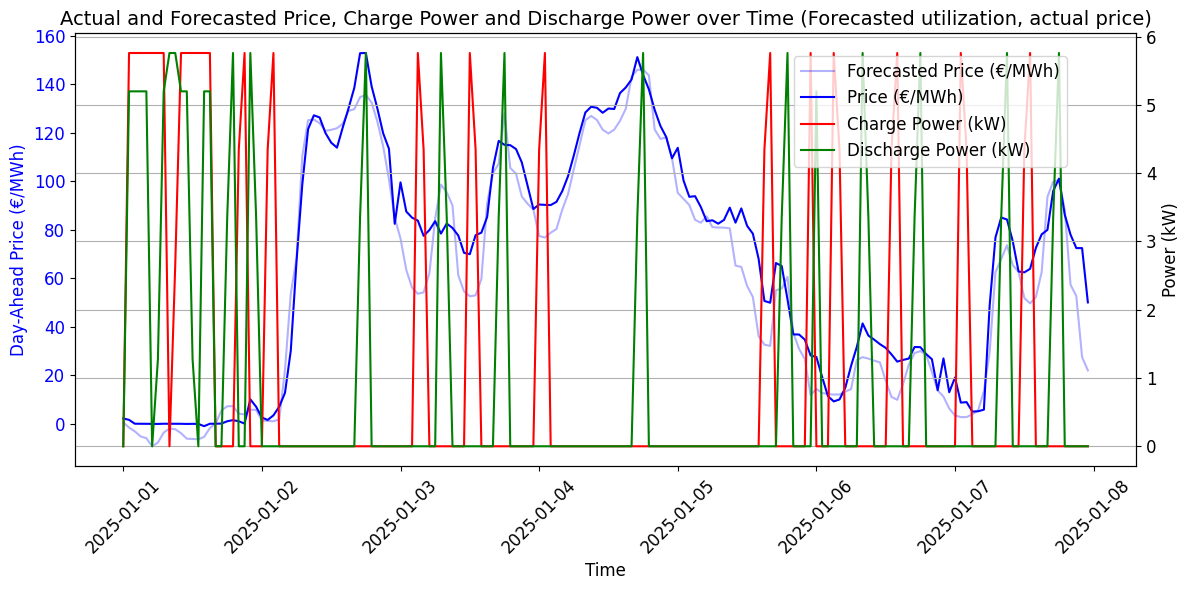

In [ ]:
# Define the path to the results file
results_path = os.path.join('Results', 'actual_results_df_2025.csv')

# Read the results CSV file into a DataFrame
actual_results_2025 = pd.read_csv(results_path, index_col=0)
# Use the correct format string for conversion
actual_results_2025.index = pd.to_datetime(actual_results_2025.index, format="%Y-%m-%d %H:%M:%S")
#Create a subset for better readability of the plot
result_subset_df_2025 = actual_results_2025.head(168)
predicted_results_subset_df_2025 = predicted_results_df_2025.head(168)
fig, ax1 = plt.subplots(figsize=(12, 6))

 # Plot price on the first y-axis
ax1.plot(result_subset_df_2025.index, predicted_results_subset_df_2025['price'],
         color='blue', alpha=0.3, label='Forecasted Price (€/MWh)')
ax1.plot(result_subset_df_2025.index, result_subset_df_2025['price'], color='blue', label='Price (€/MWh)')
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Day-Ahead Price (€/MWh)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)


# Format x-axis as days
ax1.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)



# Create a second y-axis for power
ax2 = ax1.twinx()
ax2.plot(result_subset_df_2025.index, result_subset_df_2025['P_ch'], color='red', label='Charge Power (kW)')
ax2.plot(result_subset_df_2025.index, result_subset_df_2025['P_dis'], color='green', label='Discharge Power (kW)')
ax2.set_ylabel('Power (kW)', color='black', fontsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='x', labelsize=12)

ax2.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator())
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Add title and legend
plt.title('Actual and Forecasted Price, Charge Power and Discharge Power over Time (Forecasted utilization, actual price)', fontsize=14)
fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.7), fontsize=12)

#Show the plot
plt.tight_layout()
plt.grid(True)
plt.show()

# Sensitivity Analysis

As final task in this work, we want to do a sensitivity analysis of our forecast, so we can detect, how the actual profit is effected by the forecast. Therefore, we performed two sensitivity analysis:


1.   We changed the MAE of our forecast by +-1 Euro/MWh
2.   We changed the MAE of our forecast by +-10%

Therefore, we took the price of each timestep of our forecast, compared it with the actual price and made the error smaller (+-1 Euro/MWH or +-10%)



## 1. Sensitivity Analysis (+-1 Euro/MWh)

Here we define a function to adapt the forecast prices in comparison to the actual prices (+-1 Euro/MWh). Then we added the adapted prices to a dataframe. There prices are then used to calculate a charge/discharge behavior. Finally, this behavior gets combined with the actual prices and a profit gets calculated by the optimizer.

To do so, we write two functions: One which shall decrease the MAE by shifting each value of the forecasted prices 1 Euro/MWh (or set them equal if the difference is smaller than 1 Euro/MWh) closer to the acual price and one which does the opposite.

In [ ]:
# Adjusting our predicted price by +-1€/MWh closer to the real price
#Create a new dateframe that is a copy of the forecasted_prices
forecasted_prices_corrected_df = forecasted_prices_df.copy()
#Add real price column
forecasted_prices_corrected_df.index = perfect_results_df_2025.index
forecasted_prices_corrected_df['real_price'] = perfect_results_df_2025['price']


# increasing forecasted price by 1€/MWh if diff is larger than -1 and decreasing if diff is larger than +1

def adjust_positive(forecasted_prices_corrected_df):
    forecasted_price = forecasted_prices_corrected_df['forecasted_price']
    real_price = forecasted_prices_corrected_df['real_price']

    # Case 1: abs(real_price - forecasted_price) >1
    if abs(real_price - forecasted_price) > 1:
        if real_price > forecasted_price:
            return forecasted_price + 1
        else:
            return forecasted_price - 1

    # Case 2: diff of real_price and forecasted_price < 1
    else:
        return real_price

def adjust_negative(forecasted_prices_corrected_df):
    forecasted_price = forecasted_prices_corrected_df['forecasted_price']
    real_price = forecasted_prices_corrected_df['real_price']

    if real_price > forecasted_price:
      return forecasted_price -1
    else:
      return forecasted_price +1



# Neue Spalte mit korrigierten Werten
forecasted_prices_corrected_df['corrected_price_positive'] = forecasted_prices_corrected_df.apply(adjust_positive,axis=1)
forecasted_prices_corrected_df['corrected_price_negative'] = forecasted_prices_corrected_df.apply(adjust_negative,axis=1)

display(forecasted_prices_corrected_df)

#Save the actual results as a .csv files in the Results folder
output_filename = 'forecasted_price_2025_corrected_1_Euro_MWh.csv'
output_path = os.path.join('Results', output_filename)
forecasted_prices_corrected_df.to_csv(output_path)

,forecasted_price,real_price,corrected_price_positive,corrected_price_negative
time,,,,
2025-01-01 00:00:00,0.521005,2.16,1.521005,-0.478995
2025-01-01 01:00:00,-1.592291,1.60,-0.592291,-2.592291
2025-01-01 02:00:00,-3.149149,0.00,-2.149149,-4.149149
2025-01-01 03:00:00,-5.235900,-0.01,-4.235900,-6.235900
2025-01-01 04:00:00,-5.965902,-0.01,-4.965902,-6.965902
...,...,...,...,...
2025-06-30 19:00:00,119.586363,178.94,120.586363,118.586363
2025-06-30 20:00:00,140.365055,288.97,141.365055,139.365055
2025-06-30 21:00:00,125.988069,233.35,126.988069,124.988069


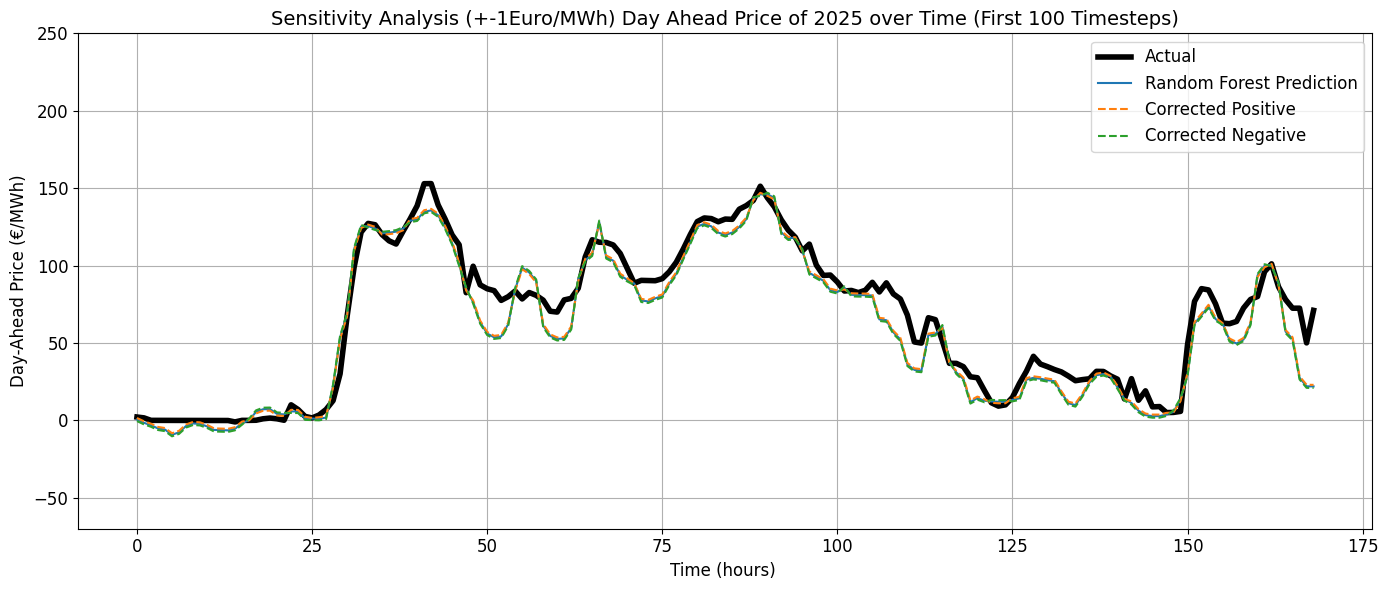

In [ ]:
# Plotting 20 timesteps to see how the sensitivity behaves in comparison with the actual price
plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(time_index_pos[:169], forecasted_prices_corrected_df['real_price'][:169],
         label='Actual', color='black', linewidth=4)

# Plot Random Forest predictions
plt.plot(time_index_pos[:169], forecasted_prices_corrected_df['forecasted_price'][:169],
         label='Random Forest Prediction', linestyle='-')
plt.plot(time_index_pos[:169], forecasted_prices_corrected_df['corrected_price_positive'][:169],
         label='Corrected Positive', linestyle='--')
plt.plot(time_index_pos[:169], forecasted_prices_corrected_df['corrected_price_negative'][:169],
         label='Corrected Negative', linestyle='--')

plt.xlabel("Time (hours) ", fontsize=12)
plt.ylabel("Day-Ahead Price (€/MWh)", fontsize=12)
plt.title("Sensitivity Analysis (+-1Euro/MWh) Day Ahead Price of 2025 over Time (First 100 Timesteps)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.ylim(-70, 250)  # Keep the same y-axis limits for consistency
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Now we run the optimizer with the correced_price_positive and see, how much profit we can get
#And how P_ch   P_dis behave


if __name__ == "__main__":
    # Example usage
    # Load price data from CSV. The included CSV along this code is just a sample
    # and should be replaced with your actual price data.
    price_csv_path = "Results/forecasted_price_2025_corrected_1_Euro_MWh.csv"
    price_df = pd.read_csv(price_csv_path, index_col=0)
    # Ensure forecasted price column is named 'corrected_price_positive'
    if "corrected_price_positive" not in price_df.columns:
        raise ValueError("CSV must contain a column named 'corrected_price_positive'.")

    # Define storage parameters <- Adjust for your specific project
    storage_params = {
        "capacity": 9.6,              #capacity in kWh
            "p_max": 5.76,            #maximum power kW
            "eff_ch": 0.95,           #charging effectivity
            "eff_dis": 0.95,          #discharging effectivity
            "soc_init": 0,            #inital state of charge
    }

    # Run optimization
    model = optimize_storage_dispatch(price_df["corrected_price_positive"], storage_params)

    # Extract profits and dispatch info
    forecasted_results_df_2025_corrected_positive = extract_storage_profits(model, price_df["corrected_price_positive"], storage_params)

    #save results as a .csv and store it in the Results folder
    output_filename = 'ch_dis_df_2025_corrected_positive_1_Euro_MWh.csv'
    output_path = os.path.join('Results', output_filename)
    forecasted_results_df_2025_corrected_positive.to_csv(output_path)
    # Print results
    print("Dispatch results positive sensitivity (head):")
    print(forecasted_results_df_2025_corrected_positive.head(104))

    #Excluded Total_profit for clarity
    #print(f"\nTotal profit: {forecasted_results_df_2025_corrected_positive['profit'].sum()/1000:.2f} k€")  # Assuming prices are in €/MWh

Dispatch results positive sensitivity (head):
                     P_ch   P_dis    E      price    profit
time                                                       
2025-01-01 00:00:00 -0.00  0.0000  0.0   1.521005  0.000000
2025-01-01 01:00:00  5.76  5.1984  0.0  -0.592291  0.332630
2025-01-01 02:00:00  5.76  5.1984  0.0  -2.149149  1.206962
2025-01-01 03:00:00  5.76  5.1984  0.0  -4.235900  2.378881
2025-01-01 04:00:00  5.76  5.1984  0.0  -4.965902  2.788851
...                   ...     ...  ...        ...       ...
2025-01-05 03:00:00  0.00  0.0000 -0.0  85.087574  0.000000
2025-01-05 04:00:00  0.00  0.0000 -0.0  83.925031  0.000000
2025-01-05 05:00:00  0.00  0.0000 -0.0  84.557212  0.000000
2025-01-05 06:00:00 -0.00  0.0000  0.0  82.103286  0.000000
2025-01-05 07:00:00  0.00  0.0000 -0.0  81.933296  0.000000

[104 rows x 5 columns]


In [ ]:
# Now we run the optimizer with the correced_price_negative and see, how much profit we can get
#And how P_ch   P_dis behave

if __name__ == "__main__":
    # Example usage
    # Load price data from CSV. The included CSV along this code is just a sample
    # and should be replaced with your actual price data.
    price_csv_path = "Results/forecasted_price_2025_corrected_1_Euro_MWh.csv"
    price_df = pd.read_csv(price_csv_path, index_col=0)
    # Ensure forecasted price column is named 'corrected_price_negative'
    if "corrected_price_negative" not in price_df.columns:
        raise ValueError("CSV must contain a column named 'corrected_price_negative'.")

    # Define storage parameters <- Adjust for your specific project
    storage_params = {
        "capacity": 9.6,              #capacity in kWh
            "p_max": 5.76,            #maximum power kW
            "eff_ch": 0.95,           #charging effectivity
            "eff_dis": 0.95,          #discharging effectivity
            "soc_init": 0,            #inital state of charge
    }

    # Run optimization
    model = optimize_storage_dispatch(price_df["corrected_price_negative"], storage_params)

    # Extract profits and dispatch info
    forecasted_results_df_2025_corrected_negative = extract_storage_profits(model, price_df["corrected_price_negative"], storage_params)

    #save results as a .csv and store it in the Results folder
    output_filename = 'ch_dis_df_2025_corrected_negative_1_Euro_MWh.csv'
    output_path = os.path.join('Results', output_filename)
    forecasted_results_df_2025_corrected_negative.to_csv(output_path)
    # Print results
    print("Dispatch results negative sensitivity (head):")
    print(forecasted_results_df_2025_corrected_negative.head(104))

    #Excluded Total_profit for clarity
    #print(f"\nTotal profit: {forecasted_results_df_2025_corrected_negative['profit'].sum()/1000:.2f} k€")  # Assuming prices are in €/MWh

Dispatch results negative sensitivity (head):
                     P_ch   P_dis    E      price    profit
time                                                       
2025-01-01 00:00:00  5.76  5.1984  0.0  -0.478995  0.269004
2025-01-01 01:00:00  5.76  5.1984  0.0  -2.592291  1.455830
2025-01-01 02:00:00  5.76  5.1984  0.0  -4.149149  2.330162
2025-01-01 03:00:00  5.76  5.1984  0.0  -6.235900  3.502081
2025-01-01 04:00:00  5.76  5.1984  0.0  -6.965902  3.912051
...                   ...     ...  ...        ...       ...
2025-01-05 03:00:00 -0.00  0.0000  0.0  83.087574  0.000000
2025-01-05 04:00:00  0.00  0.0000 -0.0  81.925031  0.000000
2025-01-05 05:00:00  0.00 -0.0000 -0.0  86.557212 -0.000000
2025-01-05 06:00:00  0.00  0.0000 -0.0  80.103286  0.000000
2025-01-05 07:00:00  0.00  0.0000 -0.0  79.933296  0.000000

[104 rows x 5 columns]


We calculate the actual profit we would make with our positive-tuned forecast (-1Euro/MWh MAE)

In [ ]:
#Create a new dataframe with P_ch, P_dis and E from positive corrected forecasted prices
# and price from predicted_results
os.path.join('Results', 'forecasted_results_df_2025_corrected_1_Euro_MWh.csv')
predicted_results_df_2025_corrected = pd.read_csv('Results/ch_dis_df_2025_corrected_positive_1_Euro_MWh.csv', index_col=0)
#First, fixing some index problems

# Create the actual_results_2025 DataFrame by selecting columns from both source dataframes
actual_results_df_2025_corrected = predicted_results_df_2025_corrected[['P_ch', 'P_dis', 'E']].copy()

# Set the index of actual_results_df_2025_corrected to match the index of perfect_results_df_2025
# This ensures that the price column is correctly aligned when assigned.
actual_results_df_2025_corrected.index = perfect_results_df_2025.index


#Add price to df
actual_results_df_2025_corrected['price'] = perfect_results_df_2025['price']

#Calculate profit
actual_results_df_2025_corrected['profit'] = (actual_results_df_2025_corrected['P_dis']
                                              * actual_results_df_2025_corrected['price']
                                              - actual_results_df_2025_corrected['P_ch']
                                              * actual_results_df_2025_corrected['price'])

#Save the actual results as a .csv files in the Results folder
output_filename = 'profit_df_2025_corrected_positive_1_Euro_MWh.csv'
output_path = os.path.join('Results', output_filename)
actual_results_df_2025_corrected.to_csv(output_path)

# Print results
print("Dispatch results with positive tuned price (-1 Euro/MWh) (head):")
print(actual_results_df_2025_corrected.head(104))
print(f"\nTotal profit with positive tuned price (-1 Euro/MWh): {actual_results_df_2025_corrected['profit'].sum()/1000:.2f} €")

Dispatch results with positive tuned price (-1 Euro/MWh) (head):
                     P_ch   P_dis    E  price    profit
time                                                   
2025-01-01 00:00:00 -0.00  0.0000  0.0   2.16  0.000000
2025-01-01 01:00:00  5.76  5.1984  0.0   1.60 -0.898560
2025-01-01 02:00:00  5.76  5.1984  0.0   0.00  0.000000
2025-01-01 03:00:00  5.76  5.1984  0.0  -0.01  0.005616
2025-01-01 04:00:00  5.76  5.1984  0.0  -0.01  0.005616
...                   ...     ...  ...    ...       ...
2025-01-05 03:00:00  0.00  0.0000 -0.0  93.87  0.000000
2025-01-05 04:00:00  0.00  0.0000 -0.0  89.38  0.000000
2025-01-05 05:00:00  0.00  0.0000 -0.0  83.55  0.000000
2025-01-05 06:00:00 -0.00  0.0000  0.0  83.92  0.000000
2025-01-05 07:00:00  0.00  0.0000 -0.0  82.53  0.000000

[104 rows x 5 columns]

Total profit with positive tuned price (-1 Euro/MWh): 235.17 €


We calculate the actual profit we would make with our negative-tuned forecast (+1 Euro/MWh)

In [ ]:
#Create a new dataframe with P_ch, P_dis and E from negative corrected forecasted prices
# and price from predicted_results
os.path.join('Results', 'forecasted_results_df_2025_corrected_1_Euro_MWh.csv')
predicted_results_df_2025_corrected = pd.read_csv('Results/ch_dis_df_2025_corrected_negative_1_Euro_MWh.csv', index_col=0)
#First, fixing some index problems

# Create the actual_results_2025 DataFrame by selecting columns from both source dataframes
actual_results_df_2025_corrected = predicted_results_df_2025_corrected[['P_ch', 'P_dis', 'E']].copy()

# Set the index of actual_results_df_2025_corrected to match the index of perfect_results_df_2025
# This ensures that the price column is correctly aligned when assigned.
actual_results_df_2025_corrected.index = perfect_results_df_2025.index


#Add price to df
actual_results_df_2025_corrected['price'] = perfect_results_df_2025['price']

#Calculate profit
actual_results_df_2025_corrected['profit'] = (actual_results_df_2025_corrected['P_dis']
                                              * actual_results_df_2025_corrected['price']
                                              - actual_results_df_2025_corrected['P_ch']
                                              * actual_results_df_2025_corrected['price'])

#Save the actual results as a .csv files in the Results folder
output_filename = 'profit_df_2025_corrected_negative_1_Euro_MWh.csv'
output_path = os.path.join('Results', output_filename)
actual_results_df_2025_corrected.to_csv(output_path)

# Print results
print("Dispatch results  with negative tuned price (+1 Euro/MWh) (head):")
print(actual_results_df_2025_corrected.head(104))
print(f"\nTotal profit with negative tuned price (+1 Euro/MWh): {actual_results_df_2025_corrected['profit'].sum()/1000:.2f} €")  # Assuming prices are in €/MWh

Dispatch results  with negative tuned price (+1 Euro/MWh) (head):
                     P_ch   P_dis    E  price    profit
time                                                   
2025-01-01 00:00:00  5.76  5.1984  0.0   2.16 -1.213056
2025-01-01 01:00:00  5.76  5.1984  0.0   1.60 -0.898560
2025-01-01 02:00:00  5.76  5.1984  0.0   0.00  0.000000
2025-01-01 03:00:00  5.76  5.1984  0.0  -0.01  0.005616
2025-01-01 04:00:00  5.76  5.1984  0.0  -0.01  0.005616
...                   ...     ...  ...    ...       ...
2025-01-05 03:00:00 -0.00  0.0000  0.0  93.87  0.000000
2025-01-05 04:00:00  0.00  0.0000 -0.0  89.38  0.000000
2025-01-05 05:00:00  0.00 -0.0000 -0.0  83.55 -0.000000
2025-01-05 06:00:00  0.00  0.0000 -0.0  83.92  0.000000
2025-01-05 07:00:00  0.00  0.0000 -0.0  82.53  0.000000

[104 rows x 5 columns]

Total profit with negative tuned price (+1 Euro/MWh): 231.01 €


## 2. Sensitivity analysis (+-10% RMSE)

Since the increase/decrease of the MAE has only a very low impact, we want to change the error even more. Therefore, we always assume a 10% decrease/increase of the error for every timestep.

Here we define a function to adapt the forecast prices in comparison to the actual prices (+-10%). Then we added the adapted prices to a dataframe. There prices are then used to calculate a charge/discharge behavior. Finally, this behavior gets combined with the actual prices and a profit gets calculated.

In [ ]:
#The following steps are similar to the steps already done for the first
#sensitivity, therefore the commenting is only focused on the main different
#steps
def adjust_positive_10_percent(forecasted_prices_corrected_df):
    forecasted_price = forecasted_prices_corrected_df['forecasted_price']
    real_price = forecasted_prices_corrected_df['real_price']

    if real_price > forecasted_price:
      return forecasted_price + (real_price - forecasted_price)/10
    else:
      return forecasted_price - (forecasted_price - real_price)/10

def adjust_negative_10_percent(forecasted_prices_corrected_df):
    forecasted_price = forecasted_prices_corrected_df['forecasted_price']
    real_price = forecasted_prices_corrected_df['real_price']

    if real_price > forecasted_price:
      return forecasted_price - (real_price - forecasted_price)/10
    else:
      return forecasted_price + (forecasted_price - real_price)/10


# Neue Spalte mit korrigierten Werten
forecasted_prices_corrected_df['corrected_price_positive_10_percent'] = forecasted_prices_corrected_df.apply(adjust_positive_10_percent,axis=1)
forecasted_prices_corrected_df['corrected_price_negative_10_percent'] = forecasted_prices_corrected_df.apply(adjust_negative_10_percent,axis=1)

print(forecasted_prices_corrected_df)

#Save the actual results as a .csv files in the Results folder
output_filename = 'forecasted_price_2025_corrected_10_percent.csv'
output_path = os.path.join('Results', output_filename)
forecasted_prices_corrected_df.to_csv(output_path)


                     forecasted_price  real_price  corrected_price_positive  \
time                                                                          
2025-01-01 00:00:00          0.521005        2.16                  1.521005   
2025-01-01 01:00:00         -1.592291        1.60                 -0.592291   
2025-01-01 02:00:00         -3.149149        0.00                 -2.149149   
2025-01-01 03:00:00         -5.235900       -0.01                 -4.235900   
2025-01-01 04:00:00         -5.965902       -0.01                 -4.965902   
...                               ...         ...                       ...   
2025-06-30 19:00:00        119.586363      178.94                120.586363   
2025-06-30 20:00:00        140.365055      288.97                141.365055   
2025-06-30 21:00:00        125.988069      233.35                126.988069   
2025-06-30 22:00:00        114.170442      157.00                115.170442   
2025-06-30 23:00:00        101.054350      122.65   

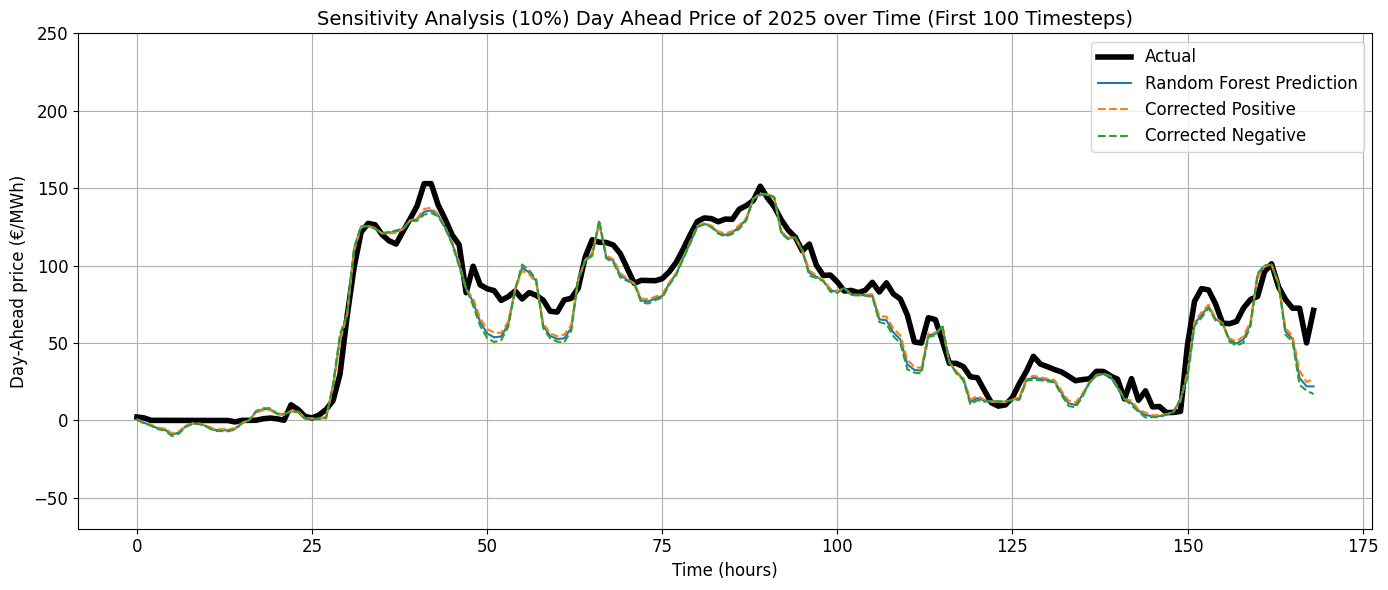

In [ ]:
# Plotting 20 timesteps to see how the sensitivity behaves in comparison with the actual price
plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(time_index_pos[:169], forecasted_prices_corrected_df['real_price'][:169], label='Actual', color='black', linewidth=4)

# Plot Random Forest predictions
plt.plot(time_index_pos[:169], forecasted_prices_corrected_df['forecasted_price'][:169], label='Random Forest Prediction', linestyle='-')
plt.plot(time_index_pos[:169], forecasted_prices_corrected_df['corrected_price_positive_10_percent'][:169], label='Corrected Positive', linestyle='--')
plt.plot(time_index_pos[:169], forecasted_prices_corrected_df['corrected_price_negative_10_percent'][:169], label='Corrected Negative', linestyle='--')

plt.xlabel("Time (hours)", fontsize=12)
plt.ylabel("Day-Ahead price (€/MWh)", fontsize=12)
plt.title("Sensitivity Analysis (10%) Day Ahead Price of 2025 over Time (First 100 Timesteps)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.ylim(-70, 250)  # Keep the same y-axis limits for consistency
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Now we run the optimizer with the correced_price_positive_10_percent and see, how much profit we can get
#And how P_ch   P_dis behave


if __name__ == "__main__":
    # Example usage
    # Load price data from CSV. The included CSV along this code is just a sample
    # and should be replaced with your actual price data.
    price_csv_path = "Results/forecasted_price_2025_corrected_10_percent.csv"
    price_df = pd.read_csv(price_csv_path, index_col=0)
    # Ensure forecasted price column is named 'corrected_price_positive_10_percent'
    if "corrected_price_positive_10_percent" not in price_df.columns:
        raise ValueError("CSV must contain a column named 'corrected_price_positive_10_percent'.")

    # Define storage parameters <- Adjust for your specific project
    storage_params = {
        "capacity": 9.6,              #capacity in kWh
            "p_max": 5.76,            #maximum power kW
            "eff_ch": 0.95,           #charging effectivity
            "eff_dis": 0.95,          #discharging effectivity
            "soc_init": 0,            #inital state of charge
    }

    # Run optimization
    model = optimize_storage_dispatch(price_df["corrected_price_positive_10_percent"], storage_params)

    # Extract profits and dispatch info
    forecasted_results_df_2025_corrected_positive = extract_storage_profits(model, price_df["corrected_price_positive_10_percent"], storage_params)

    #save results as a .csv and store it in the Results folder
    output_filename = 'ch_dis_df_2025_corrected_positive_10_percent.csv'
    output_path = os.path.join('Results', output_filename)
    forecasted_results_df_2025_corrected_positive.to_csv(output_path)
    # Print results
    #print("Dispatch results positive sensitivity (head):")
    #print(forecasted_results_df_2025_corrected_positive.head(104))

In [ ]:
# Now we run the optimizer with the correced_price_negative_10_percent and see, how much profit we can get
#And how P_ch   P_dis behave


if __name__ == "__main__":
    # Example usage
    # Load price data from CSV. The included CSV along this code is just a sample
    # and should be replaced with your actual price data.
    price_csv_path = "Results/forecasted_price_2025_corrected_10_percent.csv"
    price_df = pd.read_csv(price_csv_path, index_col=0)
    # Ensure forecasted price column is named 'corrected_price_negative_10_percent'
    if "corrected_price_negative_10_percent" not in price_df.columns:
        raise ValueError("CSV must contain a column named 'corrected_price_negative_10_percent'.")

    # Define storage parameters <- Adjust for your specific project
    storage_params = {
        "capacity": 9.6,              #capacity in kWh
            "p_max": 5.76,            #maximum power kW
            "eff_ch": 0.95,           #charging effectivity
            "eff_dis": 0.95,          #discharging effectivity
            "soc_init": 0,            #inital state of charge
    }

    # Run optimization
    model = optimize_storage_dispatch(price_df["corrected_price_negative_10_percent"], storage_params)

    # Extract profits and dispatch info
    forecasted_results_df_2025_corrected_negative = extract_storage_profits(model, price_df["corrected_price_negative_10_percent"], storage_params)

    #save results as a .csv and store it in the Results folder
    output_filename = 'ch_dis_df_2025_corrected_negative_10_percent.csv'
    output_path = os.path.join('Results', output_filename)
    forecasted_results_df_2025_corrected_negative.to_csv(output_path)
    #Print results
    #print("Dispatch results negative sensitivity (head):")
    #print(forecasted_results_df_2025_corrected_negative.head(104))

We calculate the actual profit we would make with our positive-tuned forecast (-10% MAE)

In [ ]:
#Create a new dataframe with P_ch, P_dis and E from positive corrected forecasted prices (10%)
# and price from predicted_results
os.path.join('Results', 'forecasted_results_df_2025_corrected_10_percent.csv')
predicted_results_df_2025_corrected = pd.read_csv('Results/ch_dis_df_2025_corrected_positive_10_percent.csv', index_col=0)
#First, fixing some index problems

# Create the actual_results_2025 DataFrame by selecting columns from both source dataframes
actual_results_df_2025_corrected_positive = predicted_results_df_2025_corrected[['P_ch', 'P_dis', 'E']].copy()

# Set the index of actual_results_df_2025_corrected_positive to match the index of perfect_results_df_2025
# This ensures that the price column is correctly aligned when assigned.
actual_results_df_2025_corrected_positive.index = perfect_results_df_2025.index


#Add price to df
actual_results_df_2025_corrected_positive['price'] = perfect_results_df_2025['price']

#Calculate profit
actual_results_df_2025_corrected_positive['profit'] = (actual_results_df_2025_corrected_positive['P_dis']
                                                       * actual_results_df_2025_corrected_positive['price']
                                                       - actual_results_df_2025_corrected_positive['P_ch']
                                                       * actual_results_df_2025_corrected_positive['price'])

#Save the actual results as a .csv files in the Results folder
output_filename = 'profit_df_2025_corrected_positive_10_percent.csv'
output_path = os.path.join('Results', output_filename)
actual_results_df_2025_corrected_positive.to_csv(output_path)

corrected_profit_positive_10_percent = actual_results_df_2025_corrected_positive['profit'].sum()/1000

# Print results
print("Dispatch results  with positive tuned price (-10% MAE) (head):")
print(actual_results_df_2025_corrected_positive.head(104))
print(f"\nTotal profit with positive tuned price (-10% MAE): {corrected_profit_positive_10_percent:.2f} €")

Dispatch results  with positive tuned price (-10% MAE) (head):
                     P_ch   P_dis    E  price    profit
time                                                   
2025-01-01 00:00:00 -0.00  0.0000  0.0   2.16  0.000000
2025-01-01 01:00:00  5.76  5.1984  0.0   1.60 -0.898560
2025-01-01 02:00:00  5.76  5.1984  0.0   0.00  0.000000
2025-01-01 03:00:00  5.76  5.1984  0.0  -0.01  0.005616
2025-01-01 04:00:00  5.76  5.1984  0.0  -0.01  0.005616
...                   ...     ...  ...    ...       ...
2025-01-05 03:00:00  0.00  0.0000 -0.0  93.87  0.000000
2025-01-05 04:00:00  0.00  0.0000 -0.0  89.38  0.000000
2025-01-05 05:00:00  0.00  0.0000 -0.0  83.55  0.000000
2025-01-05 06:00:00  0.00  0.0000 -0.0  83.92  0.000000
2025-01-05 07:00:00 -0.00  0.0000 -0.0  82.53  0.000000

[104 rows x 5 columns]

Total profit with positive tuned price (-10% MAE): 237.37 €


We calculate the actual profit we would make with our negative-tuned forecast (+10% MAE)

In [ ]:
#Create a new dataframe with P_ch, P_dis and E from negative corrected forecasted prices (10%)
# and price from predicted_results
os.path.join('Results', 'forecasted_results_df_2025_corrected_10_percent.csv')
predicted_results_df_2025_corrected = pd.read_csv('Results/ch_dis_df_2025_corrected_negative_10_percent.csv', index_col=0)
#First, fixing some index problems

# Create the actual_results_2025 DataFrame by selecting columns from both source dataframes
actual_results_df_2025_corrected_negative = predicted_results_df_2025_corrected[['P_ch', 'P_dis', 'E']].copy()

# Set the index of actual_results_df_2025_corrected_negative to match the index of perfect_results_df_2025
# This ensures that the price column is correctly aligned when assigned.
actual_results_df_2025_corrected_negative.index = perfect_results_df_2025.index


#Add price to df
actual_results_df_2025_corrected_negative['price'] = perfect_results_df_2025['price']

#Calculate profit
actual_results_df_2025_corrected_negative['profit'] = (actual_results_df_2025_corrected_negative['P_dis']
                                                       * actual_results_df_2025_corrected_negative['price']
                                                       - actual_results_df_2025_corrected_negative['P_ch']
                                                       * actual_results_df_2025_corrected_negative['price'])

#Save the actual results as a .csv files in the Results folder
output_filename = 'profit_df_2025_corrected_negative_10_percent.csv'
output_path = os.path.join('Results', output_filename)
actual_results_df_2025_corrected_negative.to_csv(output_path)

corrected_profit_negative_10_percent = actual_results_df_2025_corrected_negative['profit'].sum()/1000

# Print results
print("Dispatch results with positive tuned price (+10% MAE) (head):")
print(actual_results_df_2025_corrected_negative.head(104))
print(f"\nTotal profit with positive tuned price (+10% MAE): {corrected_profit_negative_10_percent:.2f} €")

Dispatch results with positive tuned price (+10% MAE) (head):
                     P_ch   P_dis    E  price    profit
time                                                   
2025-01-01 00:00:00 -0.00  0.0000  0.0   2.16  0.000000
2025-01-01 01:00:00  5.76  5.1984  0.0   1.60 -0.898560
2025-01-01 02:00:00  5.76  5.1984  0.0   0.00  0.000000
2025-01-01 03:00:00  5.76  5.1984  0.0  -0.01  0.005616
2025-01-01 04:00:00  5.76  5.1984  0.0  -0.01  0.005616
...                   ...     ...  ...    ...       ...
2025-01-05 03:00:00  0.00  0.0000 -0.0  93.87  0.000000
2025-01-05 04:00:00  0.00  0.0000 -0.0  89.38  0.000000
2025-01-05 05:00:00  0.00  0.0000 -0.0  83.55  0.000000
2025-01-05 06:00:00  0.00  0.0000 -0.0  83.92  0.000000
2025-01-05 07:00:00  0.00  0.0000 -0.0  82.53  0.000000

[104 rows x 5 columns]

Total profit with positive tuned price (+10% MAE): 223.25 €


In [ ]:
# Checking how much profit has changed
change_positive =corrected_profit_positive_10_percent/actual_generated_profit
change_negative =corrected_profit_negative_10_percent/actual_generated_profit

print('Compared to actual profit:')
print(f"\nIncrease of Profit: {(change_positive-1)*100:.2f} %")
print(f"\nDecrease of Profit: {(change_negative-1)*100:.2f} %")

print('----------------------------------------------------------------------')
print('Compared to maximum profit:')
print(f"\nDecrease Profit for Forecasted Prices:  {actual_generated_profit/theoretical_total_profit*100-100:.2f} %")
print(f"\nDecrease Profit for -10% RMSE: {corrected_profit_positive_10_percent/theoretical_total_profit*100-100:.2f} %")
print(f"\nDecrease Profit for +10% RMSE: {corrected_profit_negative_10_percent/theoretical_total_profit*100-100:.2f} %")


Compared to actual profit:

Increase of Profit: 1.67 %

Decrease of Profit: -4.38 %
----------------------------------------------------------------------
Compared to maximum profit:

Decrease Profit for Forecasted Prices:  -5.48 %

Decrease Profit for -10% RMSE: -3.90 %

Decrease Profit for +10% RMSE: -9.62 %


As a small extra, we wanted to see, how the performance of our forecasting in combination with the optimizer effects the payback period of the assumed battery system.

Therefore we assume, that a battery system costs roundabout 250 Euro/kWh, refering to a "turnkey plant" (source: ENBW). For simplification, we don't have any operating- or maintaining costs. First, we therefore calculate the cost of the total 50 MWh plant. Then we look, how much of the cost of this plant can be covered with the different profits (perfect szenario, actual profit and +-10% RSME) in the first half of 2025.

Then we assume, that for the future, the performance of the optimizer stays the same and look, after how many years our system payed itself back. For simplification, we concider the average Day-Ahead price similar to the one of the first half of 2025.

In [ ]:
#Calculate cost of battery system

cost_battery = 2930 #(Source: price-comparison)

print(f"\nAverage Day-Ahead price first half of 2025: {average_price_2025:.2f} Euro/MWh")


print(f"\nCost for the whole battery system: {cost_battery:.0f} Euro")

print("-----------------------------------------------------------------------")
print(f"Perfect price forecast:")

#Calculate how much percent of the plant is payed back after half a year
amortisation_perfect_percent = theoretical_total_profit/cost_battery
#Calculate how many years are needed to pay back the whole plant
amortisation_time = 1/amortisation_perfect_percent

print(f"\nPercentage of plant payed back after the first half of 2025: {amortisation_perfect_percent*100:.2f}%")
print(f"\nYears needed to pay back the plant: {amortisation_time:.2f} years")

print("-----------------------------------------------------------------------")
print(f"Actual price forecast:")
#Calculate how much percent of the plant is payed back after half a year
amortisation_perfect_percent = actual_generated_profit/cost_battery
#Calculate how many years are needed to pay back the whole plant
amortisation_time = 1/amortisation_perfect_percent

print(f"\nPercentage of plant payed back after the first half of 2025: {amortisation_perfect_percent*100:.2f}%")
print(f"\nYears needed to pay back the plant: {amortisation_time:.2f} years")

print("-----------------------------------------------------------------------")
print(f"Actual price forecast -10% RMSE:")
#Calculate how much percent of the plant is payed back after half a year
amortisation_perfect_percent = corrected_profit_positive_10_percent/cost_battery
#Calculate how many years are needed to pay back the whole plant
amortisation_time = 1/amortisation_perfect_percent

print(f"\nPercentage of plant payed back after the first half of 2025: {amortisation_perfect_percent*100:.2f}%")
print(f"\nYears needed to pay back the plant: {amortisation_time:.2f} years")

print("-----------------------------------------------------------------------")
print(f"Perfect price forecast +10% RMSE:")
#Calculate how much percent of the plant is payed back after half a year
amortisation_perfect_percent = corrected_profit_negative_10_percent/cost_battery
#Calculate how many years are needed to pay back the whole plant
amortisation_time = 1/amortisation_perfect_percent

print(f"\nPercentage of plant payed back after the first half of 2025: {amortisation_perfect_percent*100:.2f}%")
print(f"\nYears needed to pay back the plant: {amortisation_time:.2f} years")


Average Day-Ahead price first half of 2025: 90.71 Euro/MWh

Cost for the whole battery system: 2930 Euro
-----------------------------------------------------------------------
Perfect price forecast:

Percentage of plant payed back after the first half of 2025: 8.43%

Years needed to pay back the plant: 11.86 years
-----------------------------------------------------------------------
Actual price forecast:

Percentage of plant payed back after the first half of 2025: 7.97%

Years needed to pay back the plant: 12.55 years
-----------------------------------------------------------------------
Actual price forecast -10% RMSE:

Percentage of plant payed back after the first half of 2025: 8.10%

Years needed to pay back the plant: 12.34 years
-----------------------------------------------------------------------
Perfect price forecast +10% RMSE:

Percentage of plant payed back after the first half of 2025: 7.62%

Years needed to pay back the plant: 13.12 years


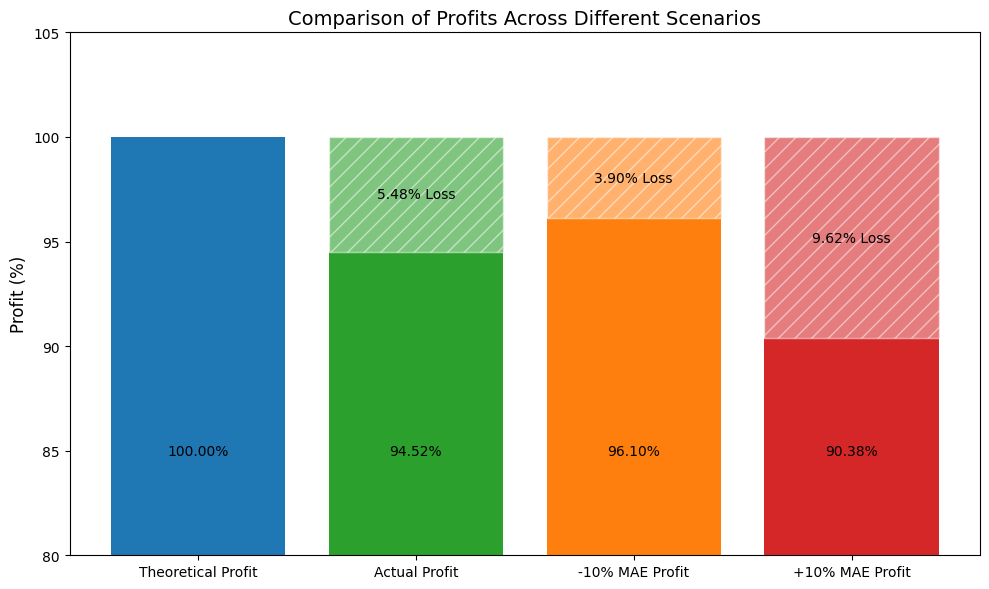

In [ ]:
# Calculate the percentage of theoretical maximum profit for each scenario
actual_profit_percent = (actual_generated_profit / theoretical_total_profit) * 100
corrected_positive_profit_percent = (corrected_profit_positive_10_percent / theoretical_total_profit) * 100
corrected_negative_profit_percent = (corrected_profit_negative_10_percent / theoretical_total_profit) * 100

# Calculate the percentage loss compared to the theoretical maximum
actual_loss_percent = 100 - actual_profit_percent
corrected_positive_loss_percent = 100 - corrected_positive_profit_percent
corrected_negative_loss_percent = 100 - corrected_negative_profit_percent


# Create labels for the bar plot
labels = ['Theoretical Profit', 'Actual Profit', '-10% MAE Profit', '+10% MAE Profit']

# Create a list of the profit percentages
profit_percentages = [100, actual_profit_percent, corrected_positive_profit_percent,
                      corrected_negative_profit_percent]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, profit_percentages, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])

# Add shaded areas for losses
plt.bar(labels[1], actual_loss_percent, bottom=actual_profit_percent,
        color='#2ca02c', alpha=0.2, label='Loss', hatch='//', ec='white')
plt.bar(labels[2], corrected_positive_loss_percent, bottom=corrected_positive_profit_percent,
        color='#ff7f0e', alpha=0.2, hatch='//', ec='white')
plt.bar(labels[3], corrected_negative_loss_percent, bottom=corrected_negative_profit_percent,
        color='#d62728', alpha=0.2, hatch='//', ec='white')


# Add labels and title
plt.ylabel('Profit (%)', fontsize=12)
plt.title('Comparison of Profits Across Different Scenarios', fontsize=14)
plt.ylim(80, 105)

# Add the percentage values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 85, f'{yval:.2f}%', ha='center', va='center', fontsize=10)

# Add loss percentages on top of the shaded areas
loss_bars = plt.bar(labels[1:], [actual_loss_percent, corrected_positive_loss_percent,
                                 corrected_negative_loss_percent],
                    bottom=[actual_profit_percent, corrected_positive_profit_percent, corrected_negative_profit_percent],
                    color=['#2ca02c', '#ff7f0e', '#d62728'], alpha=0.5, hatch='//', ec='white')
for i, bar in enumerate(loss_bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_y() + yval/2, f'{yval:.2f}% Loss', ha='center', va='center', color='black', fontsize=10)


# Show the plot
plt.tight_layout()
plt.show()

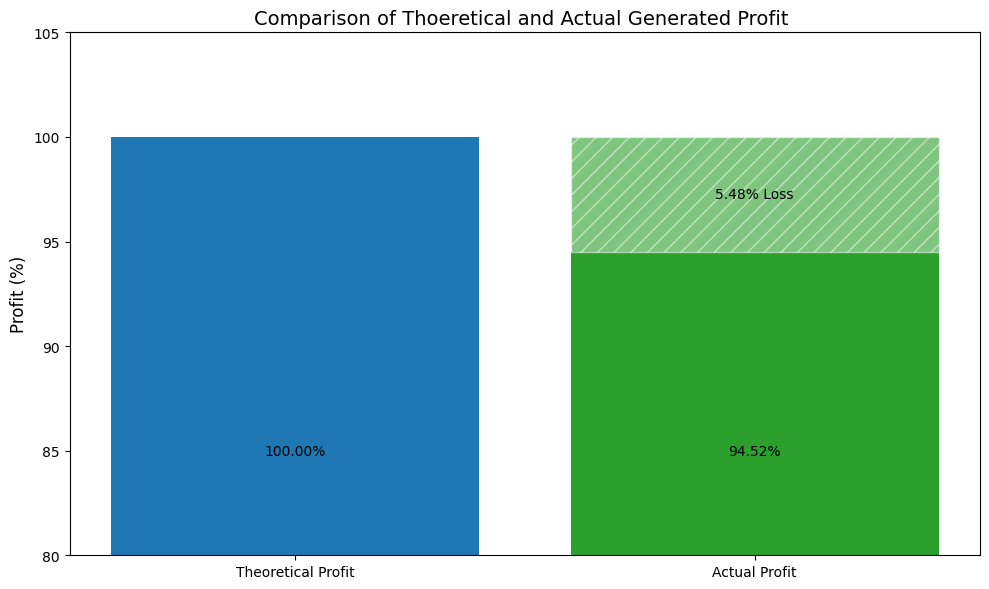

In [ ]:
# Create labels for the bar plot
labels = ['Theoretical Profit', 'Actual Profit']

# Create a list of the profit percentages
profit_percentages = [100, actual_profit_percent]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, profit_percentages, color=['#1f77b4', '#2ca02c'])

plt.bar(labels[1], actual_loss_percent, bottom=actual_profit_percent,
        color='#2ca02c', alpha=0.2, label='Loss', hatch='//', ec='white')

# Add labels and title
plt.ylabel('Profit (%)', fontsize=12)
plt.title('Comparison of Thoeretical and Actual Generated Profit ', fontsize=14)
plt.ylim(80, 105)

# Add the percentage values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 85, f'{yval:.2f}%', ha='center', va='center', fontsize=10)

# Add loss percentages on top of the shaded areas
loss_bars = plt.bar(labels[1:], actual_loss_percent,
                    bottom=actual_profit_percent,
                    color='#2ca02c', alpha=0.5, hatch='//', ec='white')
for i, bar in enumerate(loss_bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_y() + yval/2, f'{yval:.2f}% Loss', ha='center', va='center', color='black', fontsize=10)


# Show the plot
plt.tight_layout()
plt.show()

#Extra

Finally, we wanted to investigate the behavior of the price, when we adapt the RMSE more dramatically. Therefore we change it from 10%-90% in positive and negative direction, run the optimizer for each step and calculate the profit. We plot both the results for a increasing and decreasing RMSE.



FYI: This last part of the code was written out of curiosity. We weren't able to investigate it appropriately. We were not able to clean it and therefore it could be a bit messy. We will show it in the presentation as small extra in the end.

In [ ]:
#The following steps are similar to the steps already done for the first
#sensitivity, therefore the commenting is only focused on the main different
#steps

if not os.path.exists('Extra'):
    os.makedirs('Extra')


x = [10,20,30,40,50,60,70,80,90]
def adjust_positive_10_percent(forecasted_prices_corrected_df):

    forecasted_price = forecasted_prices_corrected_df['forecasted_price']
    real_price = forecasted_prices_corrected_df['real_price']
    for e in x:
      neue_spalte = f'change_{e} positive'
      if real_price > forecasted_price:
        forecasted_prices_corrected_df[neue_spalte] = forecasted_price + (real_price - forecasted_price)*e/100
      else:
        forecasted_prices_corrected_df[neue_spalte] = forecasted_price - (forecasted_price - real_price)*e/100
    return forecasted_prices_corrected_df

def adjust_negative_10_percent(forecasted_prices_corrected_df):
    forecasted_price = forecasted_prices_corrected_df['forecasted_price']
    real_price = forecasted_prices_corrected_df['real_price']
    for e in x:
      neue_spalte = f'change_{e} negative'

      if real_price > forecasted_price:
        forecasted_prices_corrected_df[neue_spalte] = forecasted_price - (real_price - forecasted_price)*e/100
      else:
        forecasted_prices_corrected_df[neue_spalte] = forecasted_price + (forecasted_price - real_price)*e/100
    return forecasted_prices_corrected_df

# Neue Spalte mit korrigierten Werten
forecasted_prices_corrected_df_positive = forecasted_prices_corrected_df.apply(adjust_positive_10_percent, axis=1)


#print(forecasted_prices_corrected_df_positive)
#print("-------------------------------------")
#print(forecasted_results_df_2025_corrected_negative)
#Save the actual results as a .csv files in the Extra folder
output_filename = 'forecasted_price_2025_corrected_positive_changes.csv'
output_path = os.path.join('Extra', output_filename)
forecasted_prices_corrected_df_positive.to_csv(output_path)

forecasted_prices_corrected_df_negative = forecasted_prices_corrected_df.apply(adjust_negative_10_percent, axis=1)

#Save the actual results as a .csv files in the Extra folder
output_filename = 'forecasted_price_2025_corrected_negative_changes.csv'
output_path = os.path.join('Extra', output_filename)
forecasted_prices_corrected_df_negative.to_csv(output_path)


In [ ]:
# Now we run the optimizer with the correced_price_positive_10_percent and see, how much profit we can get
#And how P_ch   P_dis behave
y = ["change_10 positive", "change_20 positive", "change_30 positive", "change_40 positive", "change_50 positive", "change_60 positive", "change_70 positive", "change_80 positive","change_90 positive"]
for i in y:
  if __name__ == "__main__":
      # Example usage
      # Load price data from CSV. The included CSV along this code is just a sample
      # and should be replaced with your actual price data.
      price_csv_path = "Extra/forecasted_price_2025_corrected_positive_changes.csv"
      price_df = pd.read_csv(price_csv_path, index_col=0)
      # Ensure forecasted price column is named 'corrected_price_positive_10_percent'
      if i not in price_df.columns:
          raise ValueError("CSV must contain a column named:" + str(i))

      # Define storage parameters <- Adjust for your specific project
      storage_params = {
          "capacity": 9.6,              #capacity in kWh
              "p_max": 5.76,            #maximum power kW
              "eff_ch": 0.95,           #charging effectivity
              "eff_dis": 0.95,          #discharging effectivity
              "soc_init": 0,            #inital state of charge
      }

      # Run optimization
      model = optimize_storage_dispatch(price_df[i], storage_params)

      # Extract profits and dispatch info
      d = extract_storage_profits(model, price_df[i], storage_params)

      #save results as a .csv and store it in the Extra folder
      output_filename = 'ch_dis_df_2025_corrected_positive_'+str(i)+'changes.csv'
      output_path = os.path.join('Extra', output_filename)
      d.to_csv(output_path)
      # Print results
      #print("Dispatch results positive sensitivity (head):")
      #print(forecasted_results_df_2025_corrected_positive.head(104))

In [ ]:
# Now we run the optimizer with the correced_price_positive_10_percent and see, how much profit we can get
#And how P_ch   P_dis behave
y = ["change_10 negative", "change_20 negative", "change_30 negative", "change_40 negative", "change_50 negative", "change_60 negative", "change_70 negative", "change_80 negative","change_90 negative"]
for i in y:
  if __name__ == "__main__":
      # Example usage
      # Load price data from CSV. The included CSV along this code is just a sample
      # and should be replaced with your actual price data.
      price_csv_path = "Extra/forecasted_price_2025_corrected_negative_changes.csv"
      price_df = pd.read_csv(price_csv_path, index_col=0)
      # Ensure forecasted price column is named 'corrected_price_positive_10_percent'
      if i not in price_df.columns:
          raise ValueError("CSV must contain a column named:" + str(i))

      # Define storage parameters <- Adjust for your specific project
      storage_params = {
          "capacity": 9.6,              #capacity in kWh
              "p_max": 5.76,            #maximum power kW
              "eff_ch": 0.95,           #charging effectivity
              "eff_dis": 0.95,          #discharging effectivity
              "soc_init": 0,            #inital state of charge
      }

      # Run optimization
      model = optimize_storage_dispatch(price_df[i], storage_params)

      # Extract profits and dispatch info
      d = extract_storage_profits(model, price_df[i], storage_params)

      #save results as a .csv and store it in the Extra folder
      output_filename = 'ch_dis_df_2025_corrected_negative_'+str(i)+'changes.csv'
      output_path = os.path.join('Extra', output_filename)
      d.to_csv(output_path)
      # Print results
      #print("Dispatch results positive sensitivity (head):")

In [ ]:
#Create a new dataframe with P_ch, P_dis and E from positive corrected forecasted prices (10%)
# and price from predicted_results
names = ['ch_dis_df_2025_corrected_positive_change_10 positivechanges',
'ch_dis_df_2025_corrected_positive_change_20 positivechanges',
'ch_dis_df_2025_corrected_positive_change_30 positivechanges',
'ch_dis_df_2025_corrected_positive_change_40 positivechanges',
'ch_dis_df_2025_corrected_positive_change_50 positivechanges',
'ch_dis_df_2025_corrected_positive_change_60 positivechanges',
'ch_dis_df_2025_corrected_positive_change_70 positivechanges',
'ch_dis_df_2025_corrected_positive_change_80 positivechanges',
'ch_dis_df_2025_corrected_positive_change_90 positivechanges']

profits = []
for n in names:

  os.path.join('Extra', n+'.csv')
  x = 'Extra/'+n+'.csv'
  predicted_results_df_2025_corrected = pd.read_csv(x, index_col=0)
  #First, fixing some index problems

  # Create the actual_results_2025 DataFrame by selecting columns from both source dataframes
  actual_results_df_2025_corrected_positive = predicted_results_df_2025_corrected[['P_ch', 'P_dis', 'E']].copy()

  # Set the index of actual_results_df_2025_corrected_positive to match the index of perfect_results_df_2025
  # This ensures that the price column is correctly aligned when assigned.
  actual_results_df_2025_corrected_positive.index = perfect_results_df_2025.index


  #Add price to df
  actual_results_df_2025_corrected_positive['price'] = perfect_results_df_2025['price']

  #Calculate profit
  actual_results_df_2025_corrected_positive['profit'] = (actual_results_df_2025_corrected_positive['P_dis']
                                                        * actual_results_df_2025_corrected_positive['price']
                                                        - actual_results_df_2025_corrected_positive['P_ch']
                                                        * actual_results_df_2025_corrected_positive['price'])

  corrected_profit_positive_10_percent = actual_results_df_2025_corrected_positive['profit'].sum()/1000
  profits.append(corrected_profit_positive_10_percent)

# Print results
print(profits)

[np.float64(237.3728312544266), np.float64(239.30907645885873), np.float64(241.28347180121884), np.float64(242.68485671082547), np.float64(243.91962380995014), np.float64(244.89066078182822), np.float64(245.8318207455291), np.float64(246.45605983512465), np.float64(246.83825438586152)]


In [ ]:
#Create a new dataframe with P_ch, P_dis and E from positive corrected forecasted prices (10%)
# and price from predicted_results
names = ['ch_dis_df_2025_corrected_negative_change_10 negativechanges',
'ch_dis_df_2025_corrected_negative_change_20 negativechanges',
'ch_dis_df_2025_corrected_negative_change_30 negativechanges',
'ch_dis_df_2025_corrected_negative_change_40 negativechanges',
'ch_dis_df_2025_corrected_negative_change_50 negativechanges',
'ch_dis_df_2025_corrected_negative_change_60 negativechanges',
'ch_dis_df_2025_corrected_negative_change_70 negativechanges',
'ch_dis_df_2025_corrected_negative_change_80 negativechanges',
'ch_dis_df_2025_corrected_negative_change_90 negativechanges']

profits_negative = []
for n in names:

  os.path.join('Extra', n+'.csv')
  x = 'Extra/'+n+'.csv'
  predicted_results_df_2025_corrected = pd.read_csv(x, index_col=0)
  #First, fixing some index problems

  # Create the actual_results_2025 DataFrame by selecting columns from both source dataframes
  actual_results_df_2025_corrected_positive = predicted_results_df_2025_corrected[['P_ch', 'P_dis', 'E']].copy()

  # Set the index of actual_results_df_2025_corrected_positive to match the index of perfect_results_df_2025
  # This ensures that the price column is correctly aligned when assigned.
  actual_results_df_2025_corrected_positive.index = perfect_results_df_2025.index


  #Add price to df
  actual_results_df_2025_corrected_positive['price'] = perfect_results_df_2025['price']

  #Calculate profit
  actual_results_df_2025_corrected_positive['profit'] = (actual_results_df_2025_corrected_positive['P_dis']
                                                        * actual_results_df_2025_corrected_positive['price']
                                                        - actual_results_df_2025_corrected_positive['P_ch']
                                                        * actual_results_df_2025_corrected_positive['price'])

  corrected_profit_positive_10_percent = actual_results_df_2025_corrected_positive['profit'].sum()/1000
  profits_negative.append(corrected_profit_positive_10_percent)

# Print results
print(profits_negative)

[np.float64(223.2450872471136), np.float64(207.32753732330195), np.float64(190.86311700325763), np.float64(175.92685841737398), np.float64(159.93699915044877), np.float64(144.0240689217507), np.float64(129.6995581905374), np.float64(114.20535286431024), np.float64(97.16111767379502)]


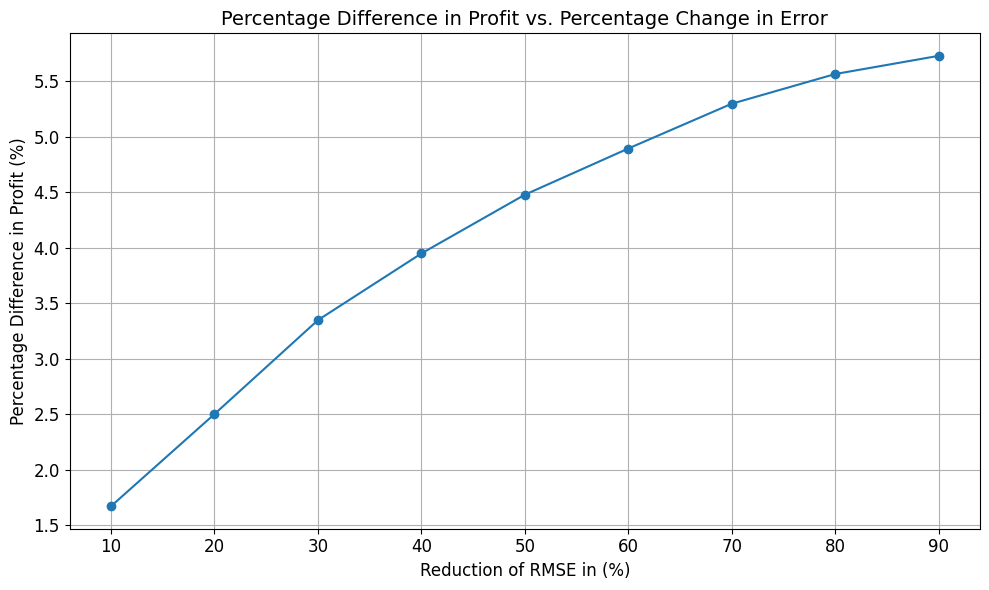

In [ ]:
# Calculate the percentage difference from the actual profit for each profit in the list
percentage_differences = [(profit-actual_generated_profit) / actual_generated_profit *100 for profit in profits]

# Define the percentage changes in RMSE for the x-axis
rmse_percentage_changes = [10, 20, 30, 40, 50, 60, 70, 80, 90]

plt.figure(figsize=(10, 6))
plt.plot(rmse_percentage_changes, percentage_differences, marker='o', linestyle='-')

plt.xlabel("Reduction of RMSE in (%)", fontsize=12)
plt.ylabel("Percentage Difference in Profit (%)", fontsize=12)
plt.title("Percentage Difference in Profit vs. Percentage Change in Error", fontsize=14)
plt.grid(True)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

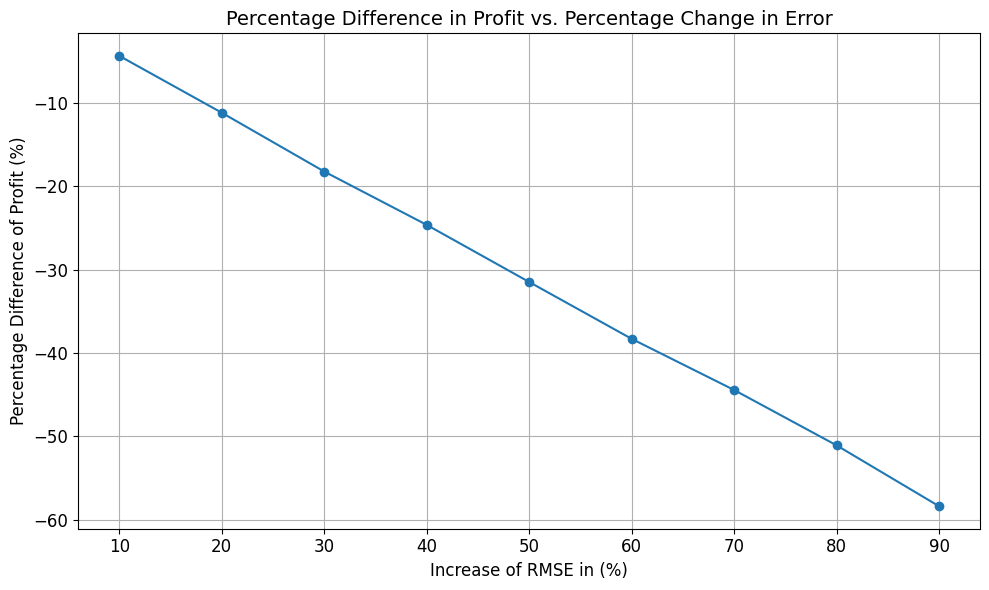

In [ ]:
# Calculate the percentage difference from the actual profit for each profit in the list
percentage_differences = [(profit-actual_generated_profit) / actual_generated_profit *100 for profit in profits_negative]

# Define the percentage changes in RMSE for the x-axis
rmse_percentage_changes = [10, 20, 30, 40, 50, 60, 70, 80, 90]

plt.figure(figsize=(10, 6))
plt.plot(rmse_percentage_changes, percentage_differences, marker='o', linestyle='-')

plt.xlabel("Increase of RMSE in (%)", fontsize=12)
plt.ylabel("Percentage Difference of Profit (%)", fontsize=12)
plt.title("Percentage Difference in Profit vs. Percentage Change in Error", fontsize=14)
plt.grid(True)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()